In [57]:
# Import dan persiapan data
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('status_mutu_air.csv')

df.head()

,No,provinsi,Sungai,2017,2018,2019,2020,2021,2022
0,1,ACEH,Krueng Tamiang,Cemar Sedang,Cemar Ringan Cemar Sedang,Cemar RinganCemar Sedang,Cemar Ringan,Cemar Ringan,Cemar Ringan
1,2,ACEH,Krueng Baroe,NaN,NaN,NaN,NaN,Cemar Ringan,Cemar Ringan
2,3,SUMATERA UTARA,Batahan,Cemar Sedang,Cemar Sedang,Cemar Sedang,Cemar Ringan,Cemar Ringan,Cemar Ringan
3,4,SUMATERA UTARA,Asahan,NaN,NaN,Cemar Berat,Cemar Ringan,Cemar Ringan,Memenuhi Cemar Ringan
4,5,SUMATERA BARAT,Batanghari,Cemar Berat,Cemar Berat,Cemar Berat,NaN,Cemar Ringan,Cemar Ringan


In [58]:
# mengecek nilai null/NaN
df.isnull().sum()

No           0
provinsi     0
Sungai       0
2017        44
2018        44
2019        34
2020        38
2021        24
2022        15
dtype: int64

In [59]:
# melakukan cleansing dengan mengisi nilai null berdasarkan data pada tahun sebelumnya
df.iloc[:, 3:] = df.iloc[:, 3:].ffill(axis=1)
df.head()

,No,provinsi,Sungai,2017,2018,2019,2020,2021,2022
0,1,ACEH,Krueng Tamiang,Cemar Sedang,Cemar Ringan Cemar Sedang,Cemar RinganCemar Sedang,Cemar Ringan,Cemar Ringan,Cemar Ringan
1,2,ACEH,Krueng Baroe,NaN,NaN,NaN,NaN,Cemar Ringan,Cemar Ringan
2,3,SUMATERA UTARA,Batahan,Cemar Sedang,Cemar Sedang,Cemar Sedang,Cemar Ringan,Cemar Ringan,Cemar Ringan
3,4,SUMATERA UTARA,Asahan,NaN,NaN,Cemar Berat,Cemar Ringan,Cemar Ringan,Memenuhi Cemar Ringan
4,5,SUMATERA BARAT,Batanghari,Cemar Berat,Cemar Berat,Cemar Berat,Cemar Berat,Cemar Ringan,Cemar Ringan


In [60]:
# melakukan cleansing dengan mengisi nilai null berdasarkan data pada tahun setelahnya
df.iloc[:, 3:] = df.iloc[:, 3:].bfill(axis=1)

# menyimpan file yang sudah dibersihkan ke csv
df.to_csv("status_mutu_air_cleaned.csv", index=False)

df.head()

,No,provinsi,Sungai,2017,2018,2019,2020,2021,2022
0,1,ACEH,Krueng Tamiang,Cemar Sedang,Cemar Ringan Cemar Sedang,Cemar RinganCemar Sedang,Cemar Ringan,Cemar Ringan,Cemar Ringan
1,2,ACEH,Krueng Baroe,Cemar Ringan,Cemar Ringan,Cemar Ringan,Cemar Ringan,Cemar Ringan,Cemar Ringan
2,3,SUMATERA UTARA,Batahan,Cemar Sedang,Cemar Sedang,Cemar Sedang,Cemar Ringan,Cemar Ringan,Cemar Ringan
3,4,SUMATERA UTARA,Asahan,Cemar Berat,Cemar Berat,Cemar Berat,Cemar Ringan,Cemar Ringan,Memenuhi Cemar Ringan
4,5,SUMATERA BARAT,Batanghari,Cemar Berat,Cemar Berat,Cemar Berat,Cemar Berat,Cemar Ringan,Cemar Ringan


In [61]:
# mengecek kembali data null setelah proses cleansing
df.isnull().sum()

No          0
provinsi    0
Sungai      0
2017        0
2018        0
2019        0
2020        0
2021        0
2022        0
dtype: int64

In [62]:
# menyamaratakan kategori dengan menghilangkan spasi dan membuat semua kata ke huruf kecil
df.iloc[:,3:] = df.iloc[:,3:].map(
    lambda x: x.lower().replace(" ", "")
)

df.head()

,No,provinsi,Sungai,2017,2018,2019,2020,2021,2022
0,1,ACEH,Krueng Tamiang,cemarsedang,cemarringancemarsedang,cemarringancemarsedang,cemarringan,cemarringan,cemarringan
1,2,ACEH,Krueng Baroe,cemarringan,cemarringan,cemarringan,cemarringan,cemarringan,cemarringan
2,3,SUMATERA UTARA,Batahan,cemarsedang,cemarsedang,cemarsedang,cemarringan,cemarringan,cemarringan
3,4,SUMATERA UTARA,Asahan,cemarberat,cemarberat,cemarberat,cemarringan,cemarringan,memenuhicemarringan
4,5,SUMATERA BARAT,Batanghari,cemarberat,cemarberat,cemarberat,cemarberat,cemarringan,cemarringan


In [63]:
# mengecek ada kategori apa saja pada data tersebut
value_keseluruhan = df.iloc[:,3:].stack()

value_unik = sorted(value_keseluruhan.unique())

for i in value_unik:
    print(i)

cemarberat
cemarringan
cemarringancemarberat
cemarringancemarringan
cemarringancemarsedang
cemarringansedang
cemarsedang
cemarsedangberat
cemarsedangcemarberat
memenuhi
memenuhicemarringan
memenuhicemarringancemarberat


In [64]:
# membuat mapping berdasarkan bobot kategori nya
kategori_mapping = {
    'memenuhi' : 0,
    'memenuhicemarringan' : 5,
    'cemarringan' : 10,
    'cemarringancemarringan' : 10,
    'cemarringancemarsedang' : 15,
    'cemarringansedang' : 15,
    'cemarringancemarberat' : 18,
    'cemarsedang' : 20,
    'cemarsedangcemarberat' : 25,
    'cemarsedangberat' : 25,
    'memenuhicemarringancemarberat' : 25,
    'cemarberat' : 30
}

df.iloc[:, 3:] = df.iloc[:, 3:].replace(kategori_mapping)

df.head()

C:\Users\whydo\AppData\Local\Temp\ipykernel_16284\4144112367.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.iloc[:, 3:] = df.iloc[:, 3:].replace(kategori_mapping)


,No,provinsi,Sungai,2017,2018,2019,2020,2021,2022
0,1,ACEH,Krueng Tamiang,20,15,15,10,10,10
1,2,ACEH,Krueng Baroe,10,10,10,10,10,10
2,3,SUMATERA UTARA,Batahan,20,20,20,10,10,10
3,4,SUMATERA UTARA,Asahan,30,30,30,10,10,5
4,5,SUMATERA BARAT,Batanghari,30,30,30,30,10,10


In [65]:
# inisiasi dictionary kosong
mutu_dict = {}

# melakukan iterasi pada data di df untuk dimasukkan ke dictionary
for index, row in df.iterrows():
    provinsi = row['provinsi']
    sungai = row['Sungai']
    mutu_list = [row['2017'],row['2018'],row['2019'],row['2020'],row['2021'],row['2022']]
    if provinsi in mutu_dict:
        mutu_dict[provinsi][sungai] = mutu_list
    else:
        mutu_dict[provinsi] = {sungai : mutu_list}

mutu_dict

{'ACEH': {'Krueng Tamiang': [20, 15, 15, 10, 10, 10],
  'Krueng Baroe': [10, 10, 10, 10, 10, 10]},
 'SUMATERA UTARA': {'Batahan': [20, 20, 20, 10, 10, 10],
  'Asahan': [30, 30, 30, 10, 10, 5]},
 'SUMATERA BARAT': {'Batanghari': [30, 30, 30, 30, 10, 10],
  'Batang Kampar': [25, 30, 30, 30, 30, 30],
  'Batang Kuantan': [25, 25, 30, 30, 10, 10],
  'Batang Anai': [10, 10, 10, 10, 10, 10],
  'Batang Ombilin': [10, 10, 10, 10, 10, 10],
  'Batang Sinamar': [10, 10, 10, 10, 10, 10]},
 'RIAU': {'Indragiri': [25, 25, 25, 25, 25, 25],
  'Siak': [30, 25, 30, 25, 10, 10],
  'Rokan': [25, 25, 25, 25, 25, 25],
  'Kampar': [25, 25, 25, 25, 25, 10]},
 'JAMBI': {'Batanghari': [15, 15, 20, 20, 10, 10],
  'Batang Tembesi': [10, 10, 10, 10, 10, 10],
  'Batang Tebo': [0, 0, 0, 0, 0, 0],
  'Batang Tabir': [10, 10, 10, 10, 10, 10]},
 'SUMATERA SELATAN': {'Musi': [30, 25, 30, 30, 10, 15],
  'Temam': [0, 0, 0, 0, 0, 0],
  'Megang': [0, 0, 0, 0, 0, 0]},
 'BENGKULU': {'Musi': [15, 15, 15, 15, 15, 15]},
 'LAMPUNG'

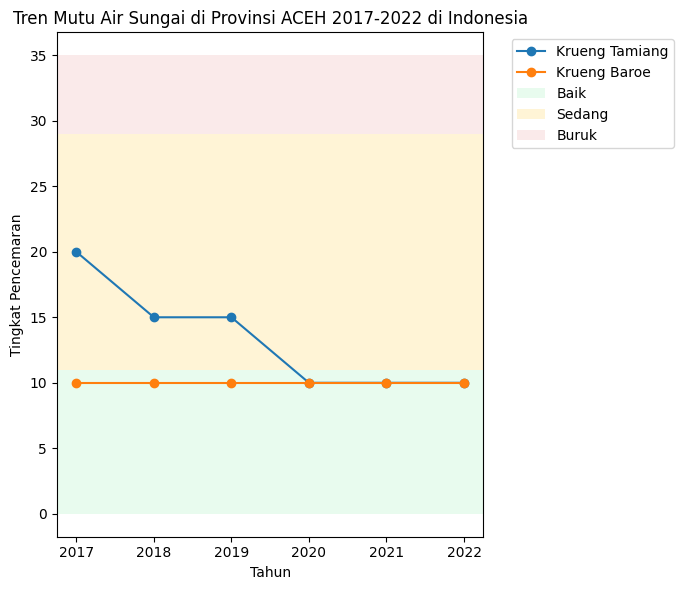

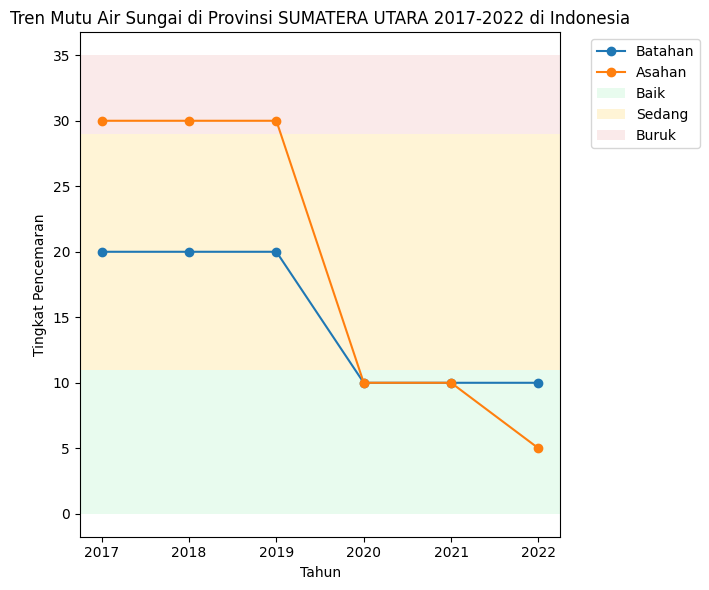

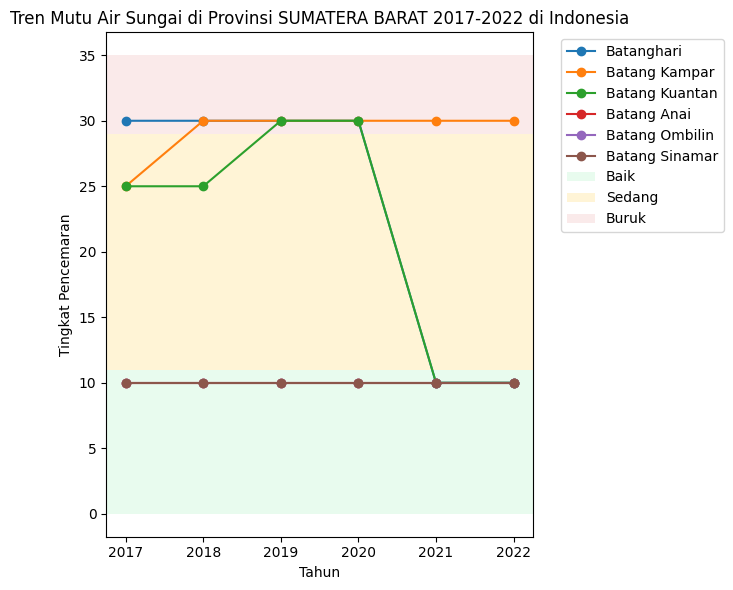

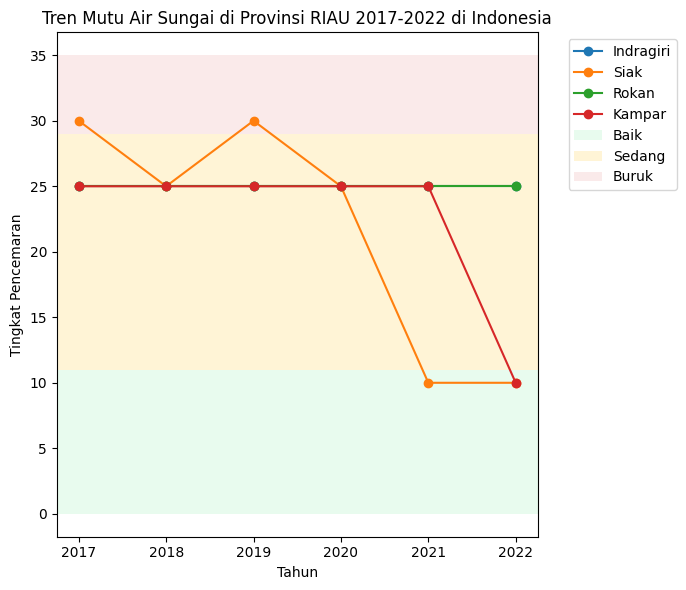

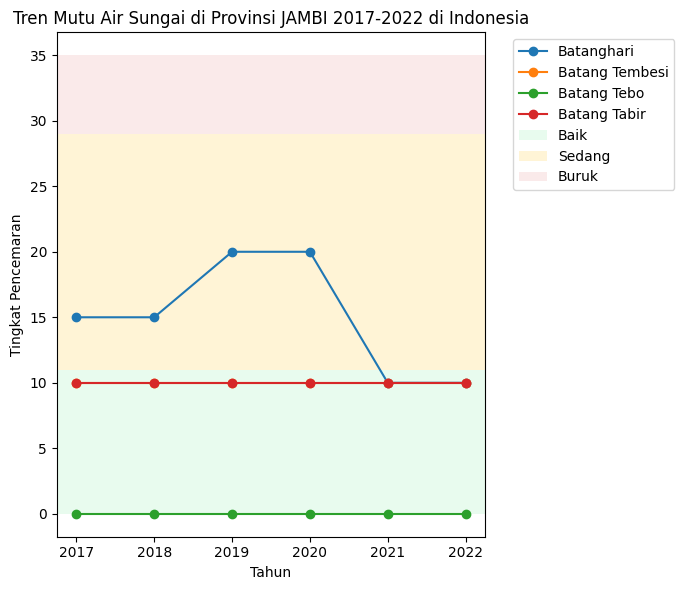

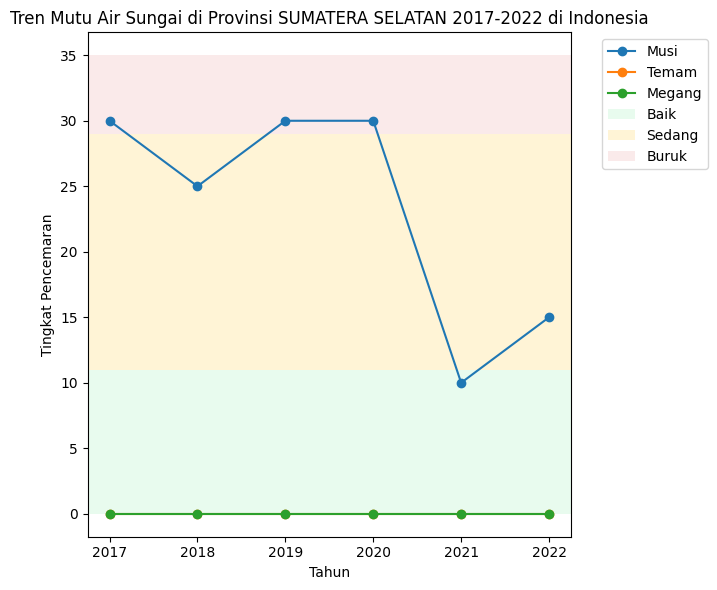

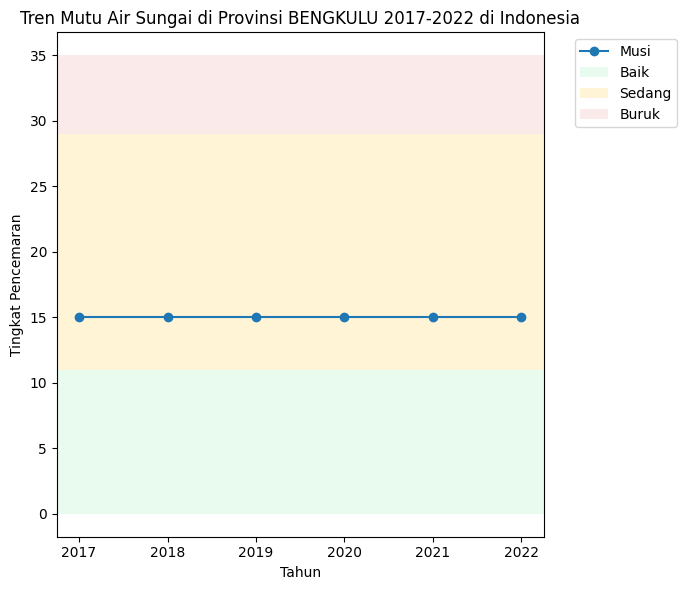

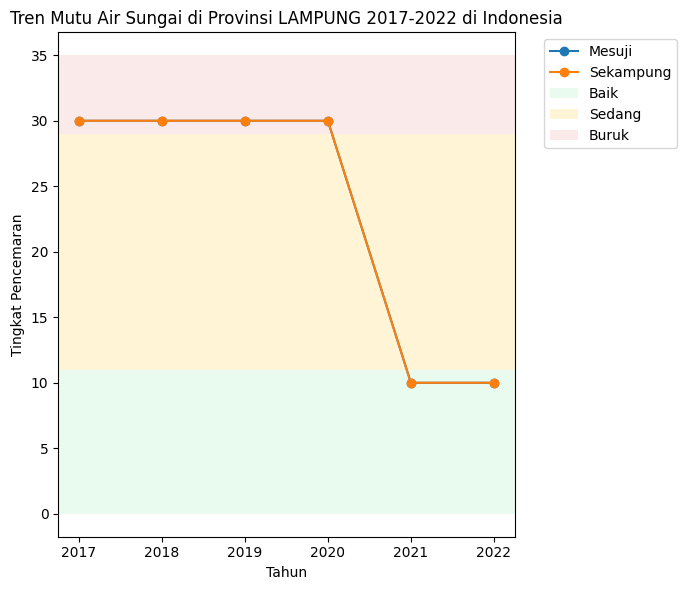

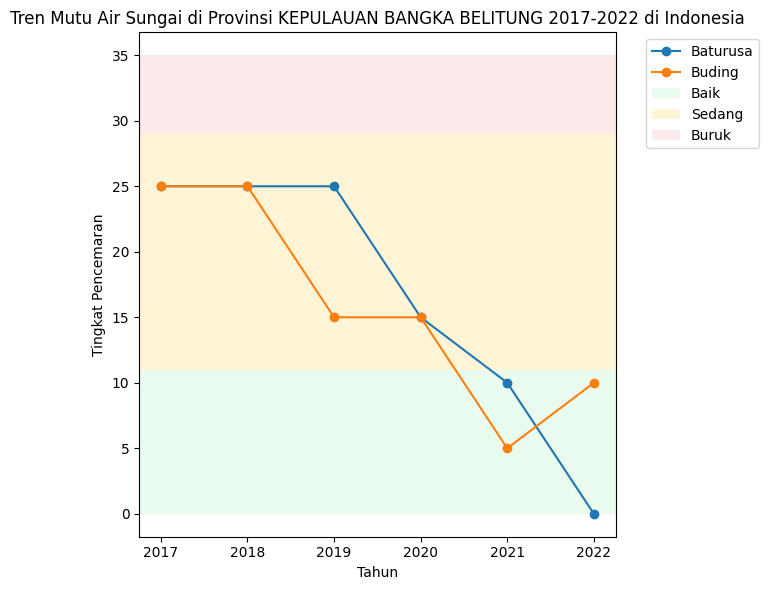

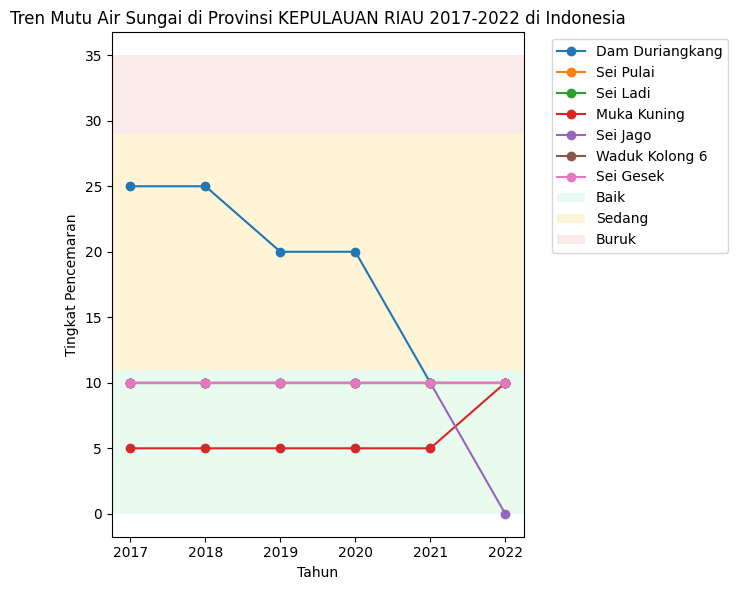

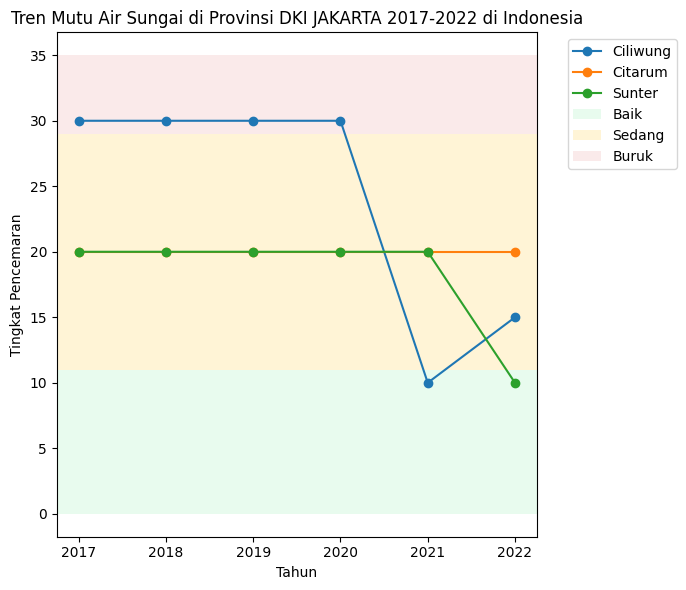

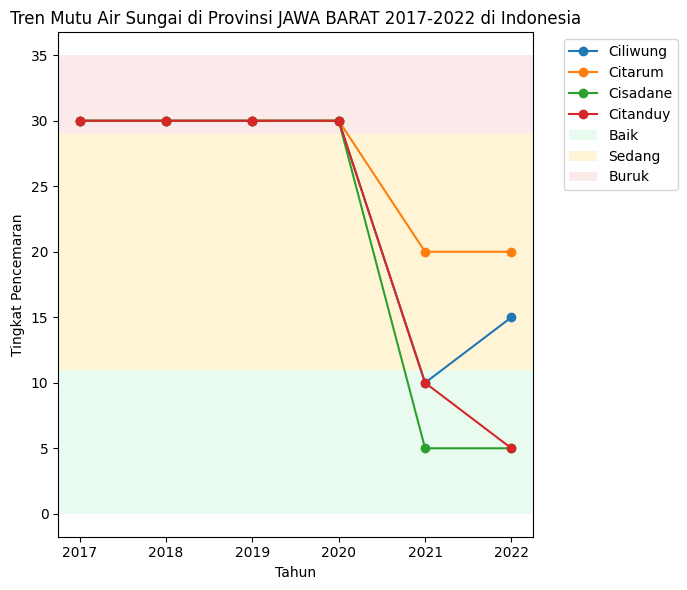

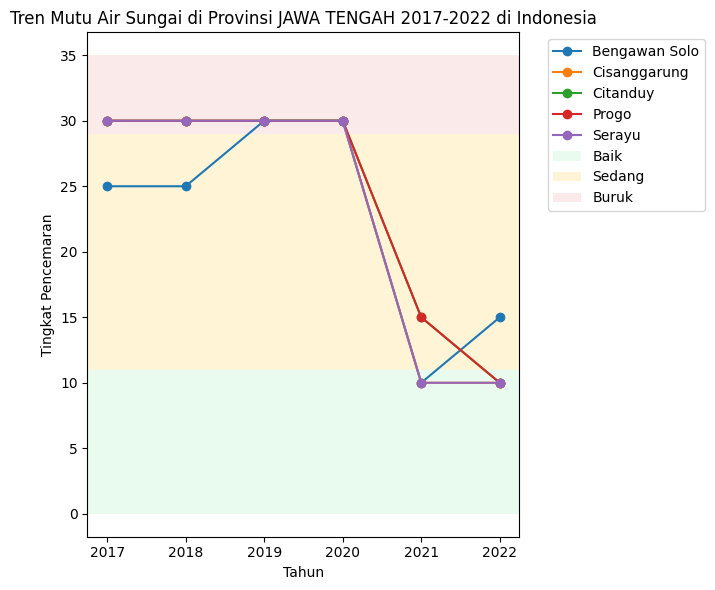

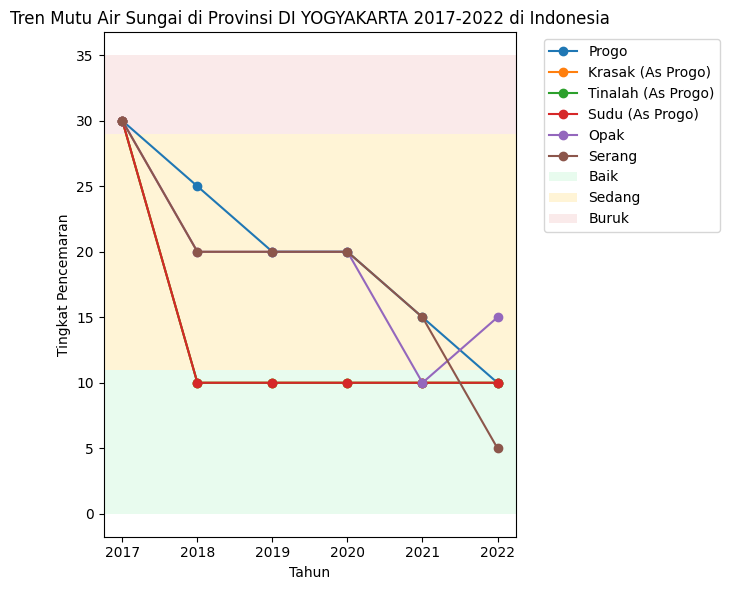

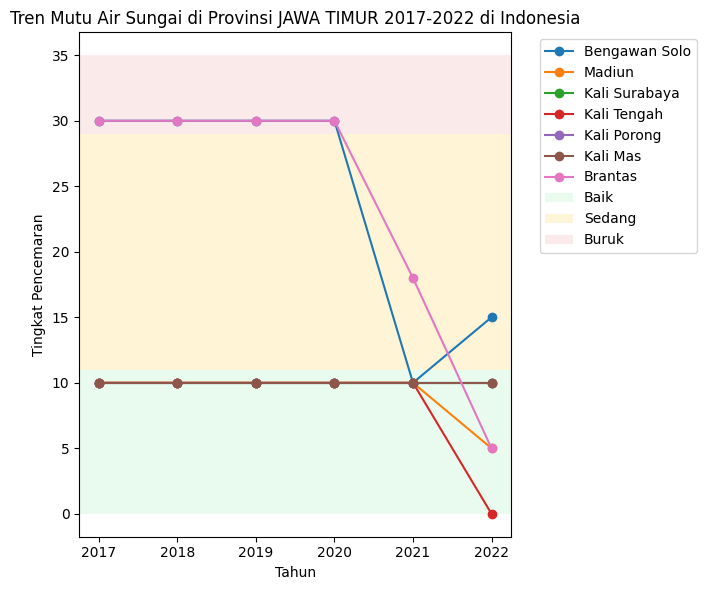

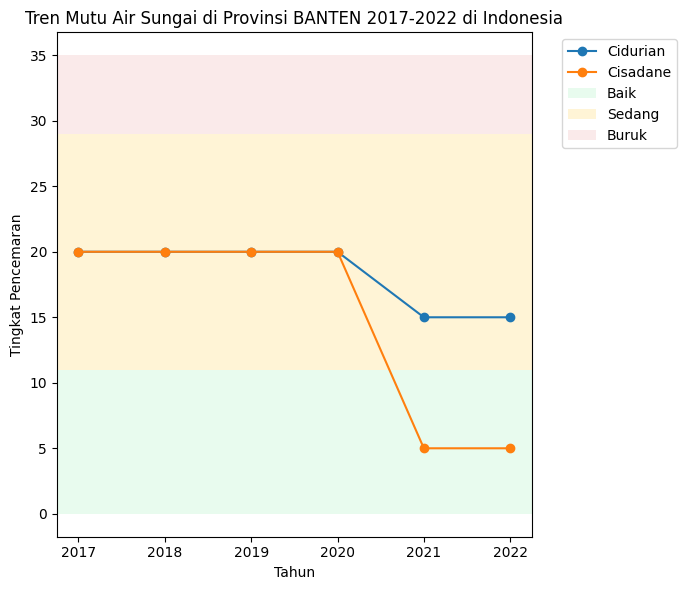

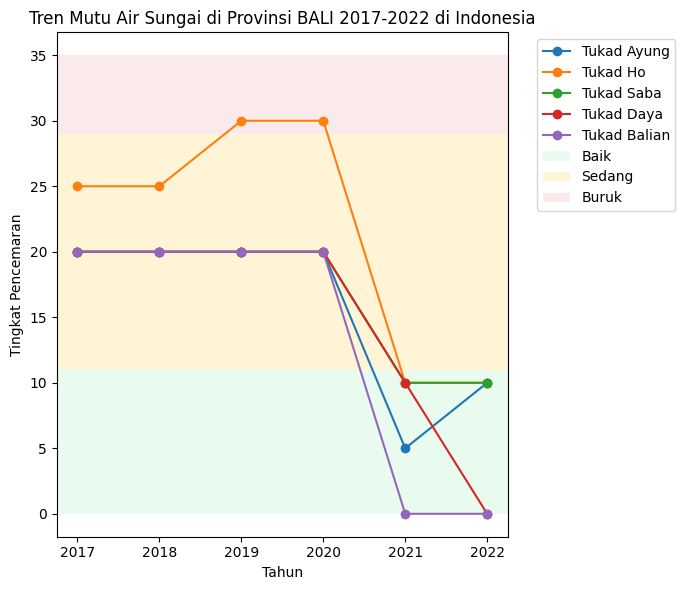

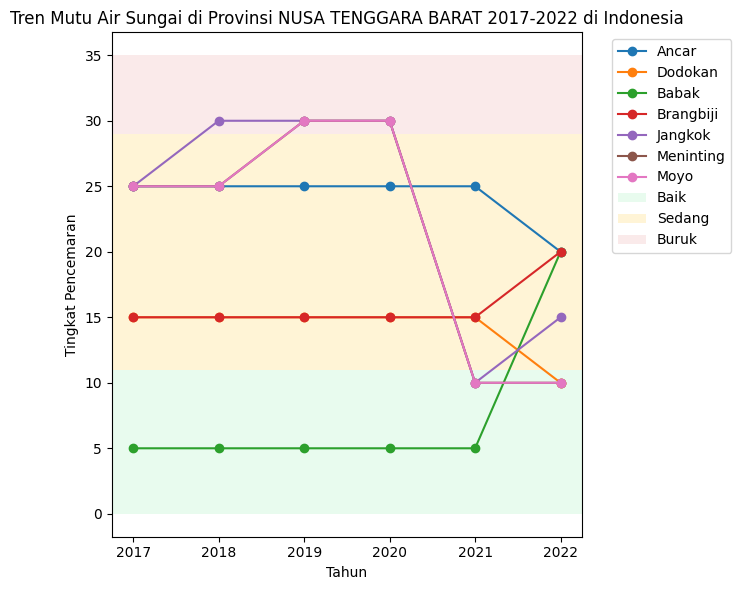

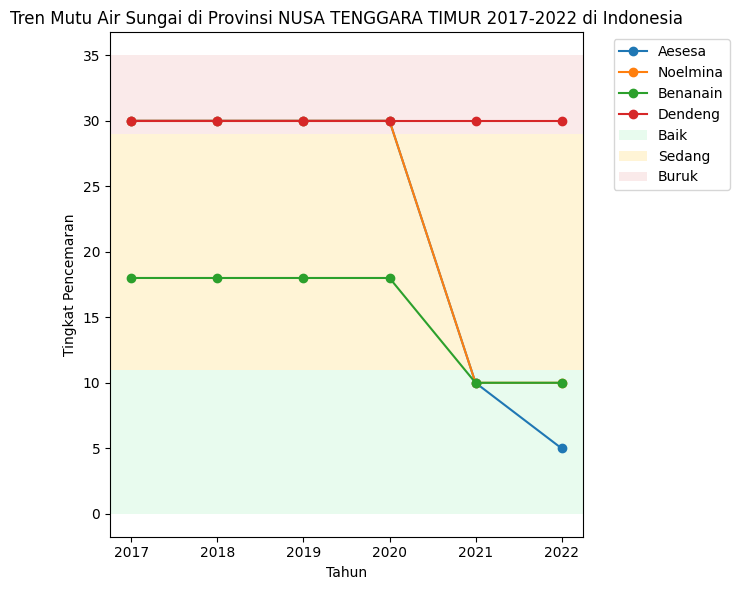

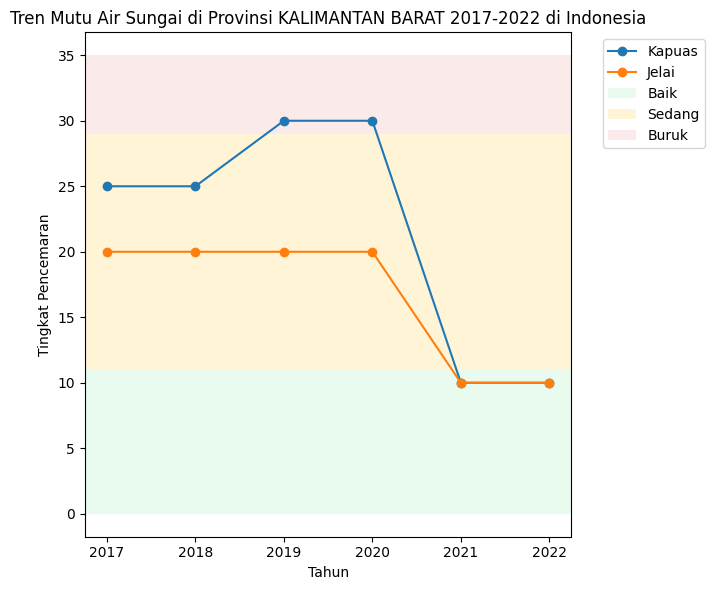

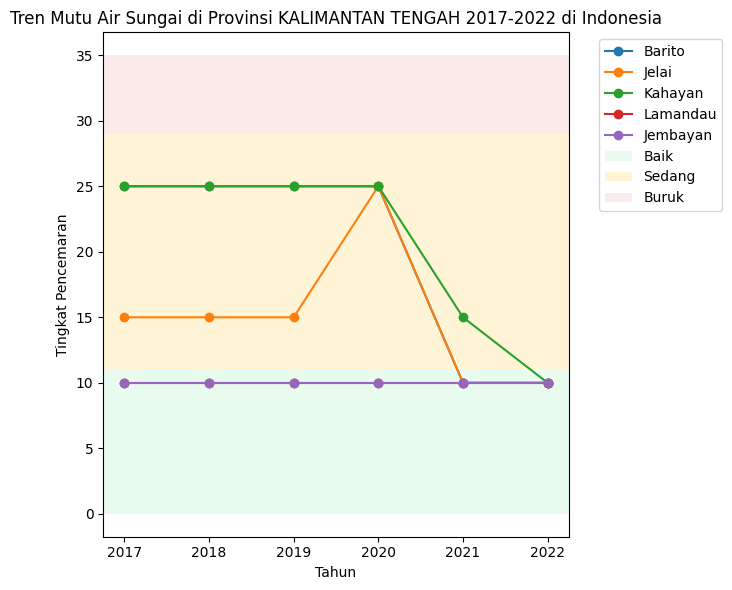

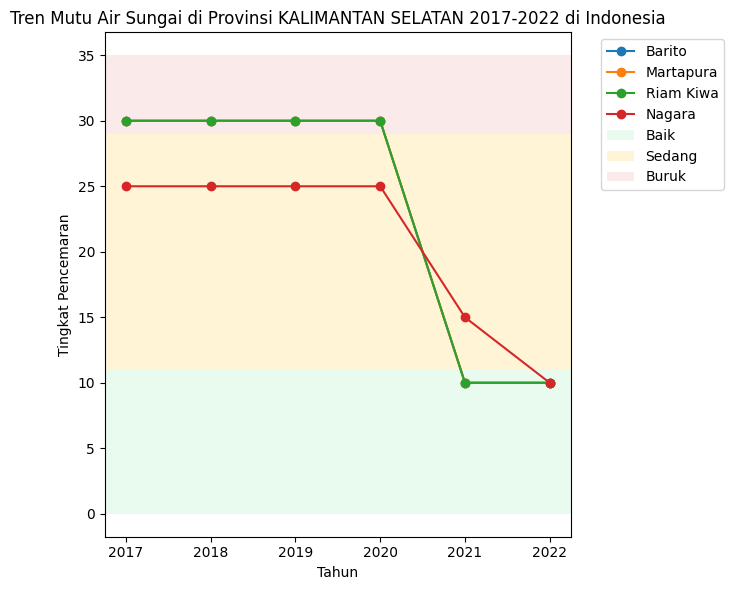

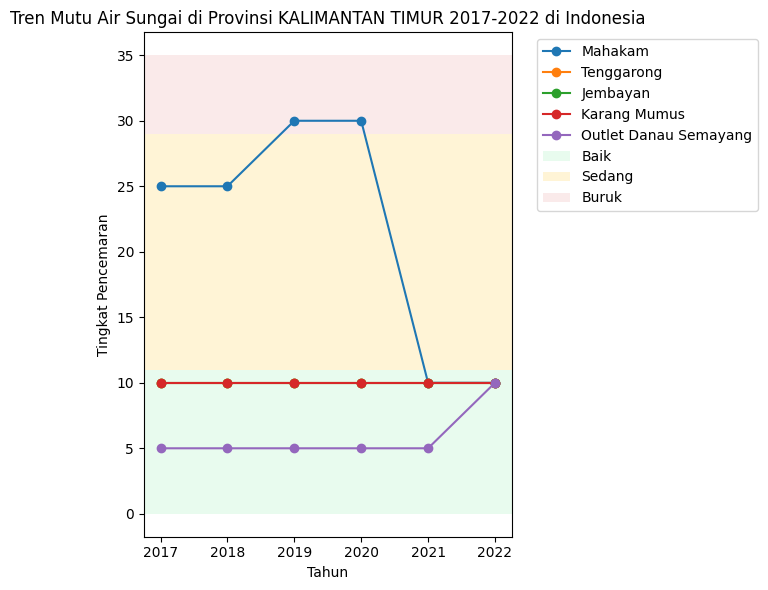

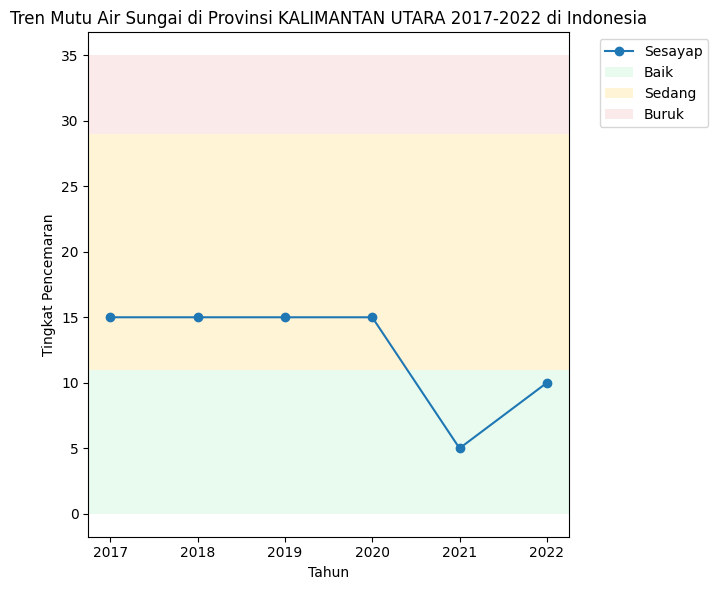

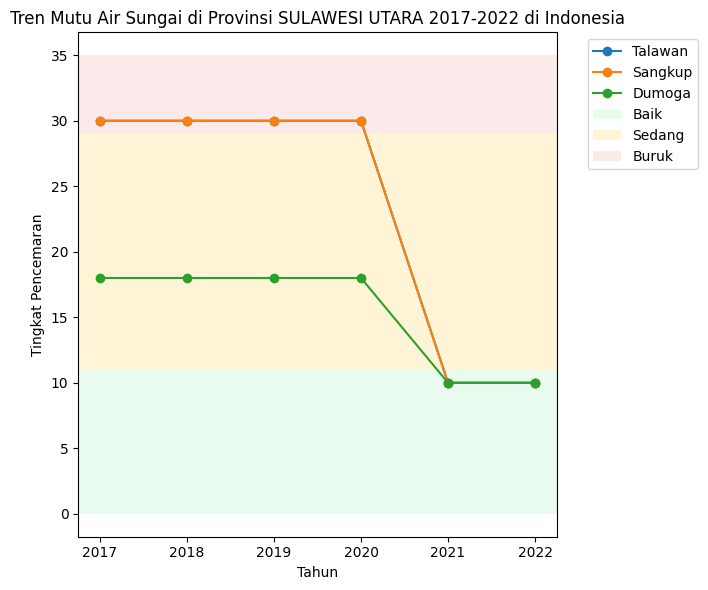

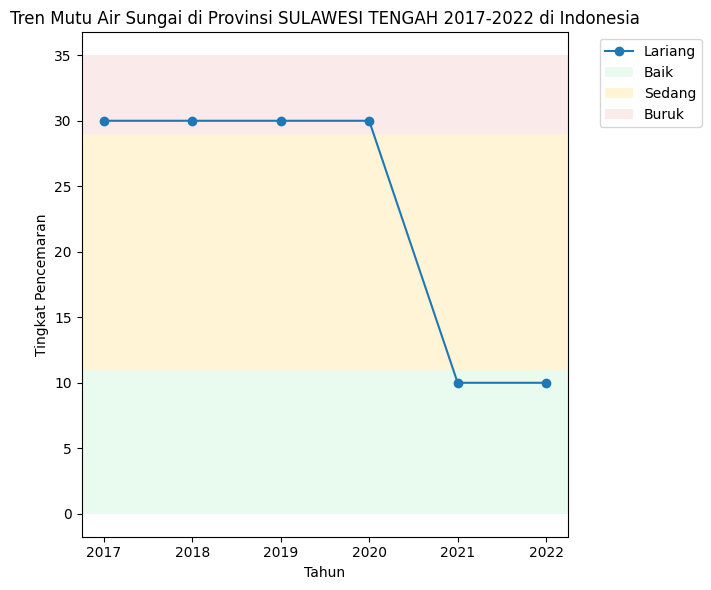

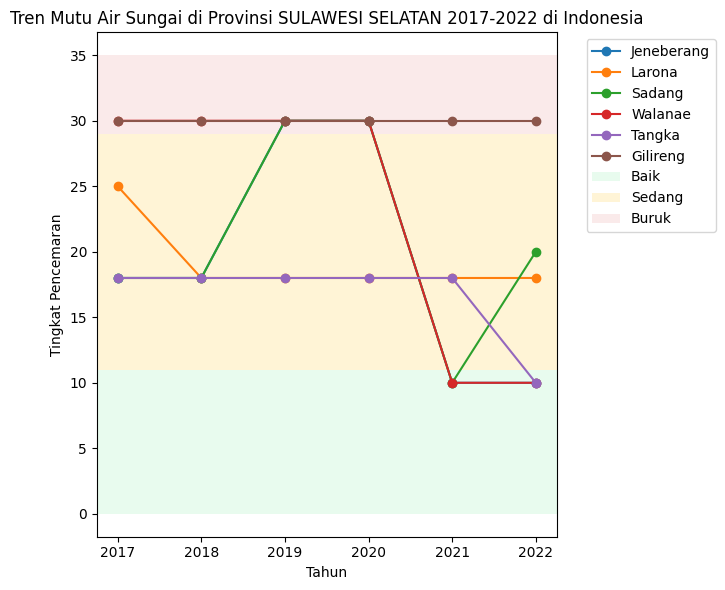

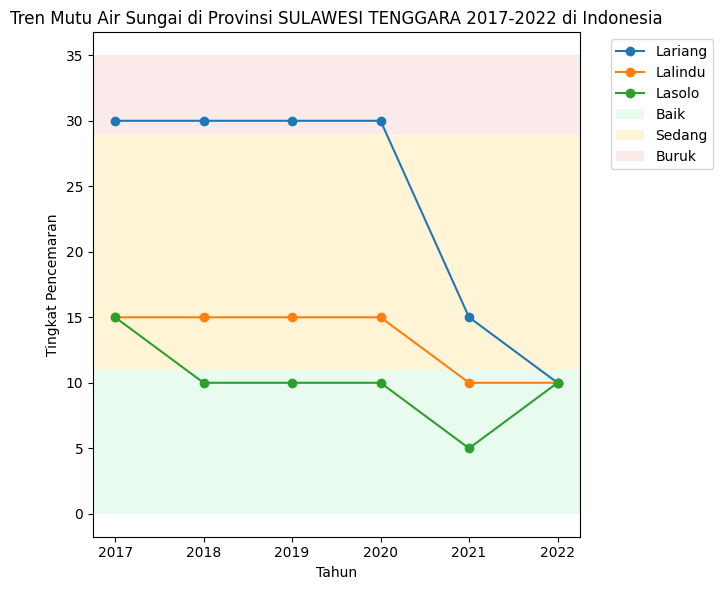

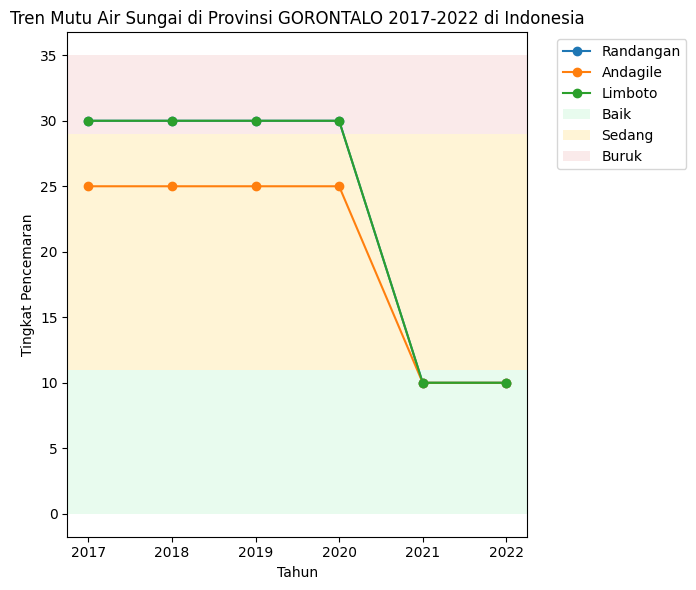

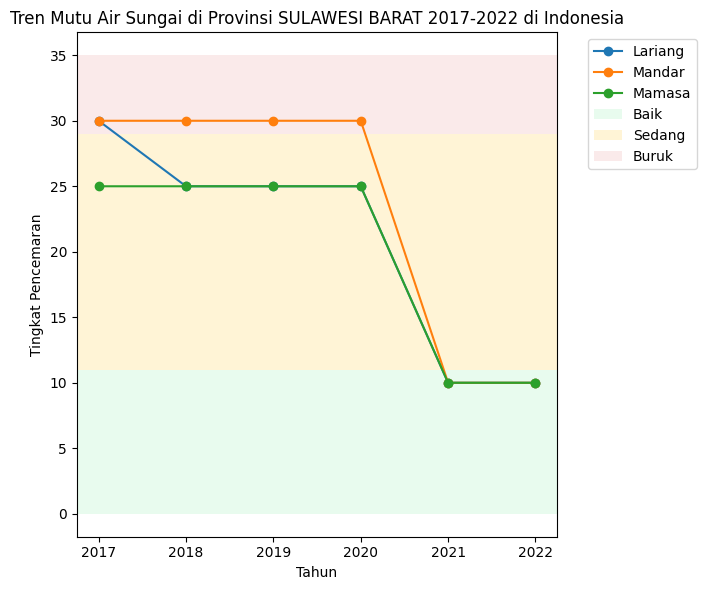

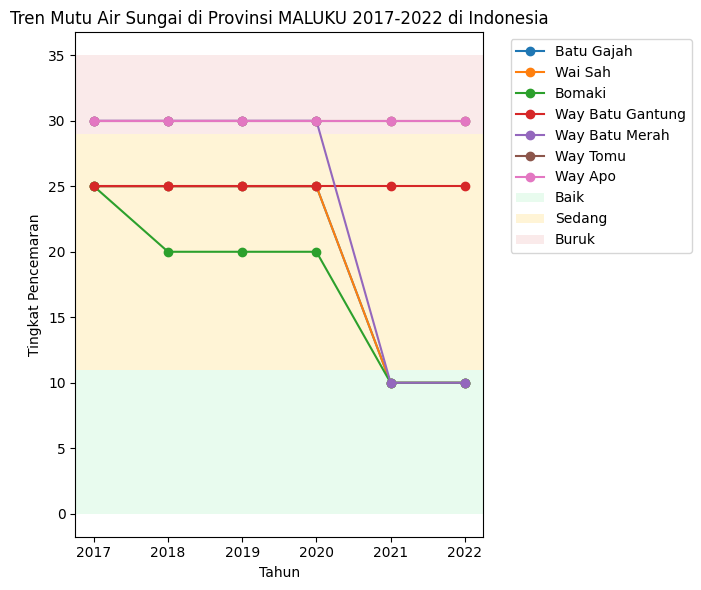

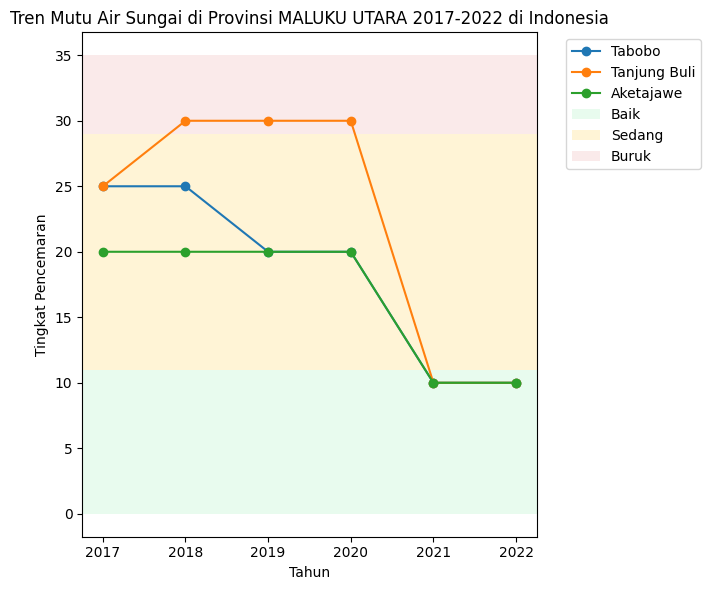

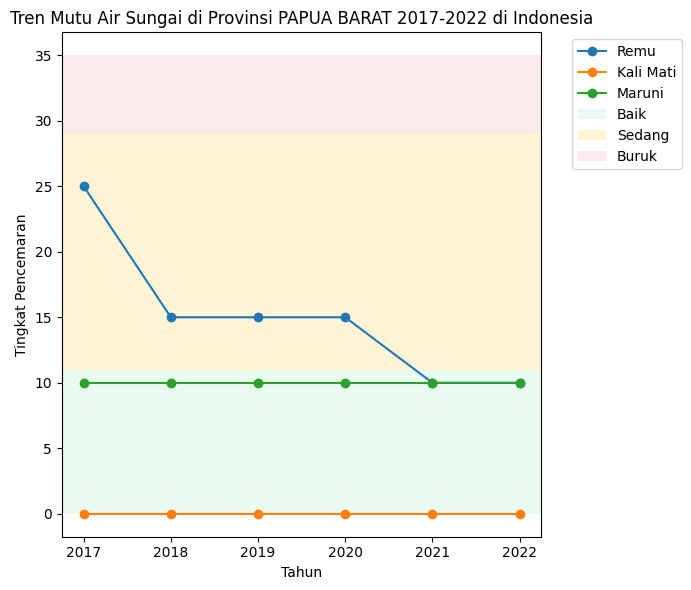

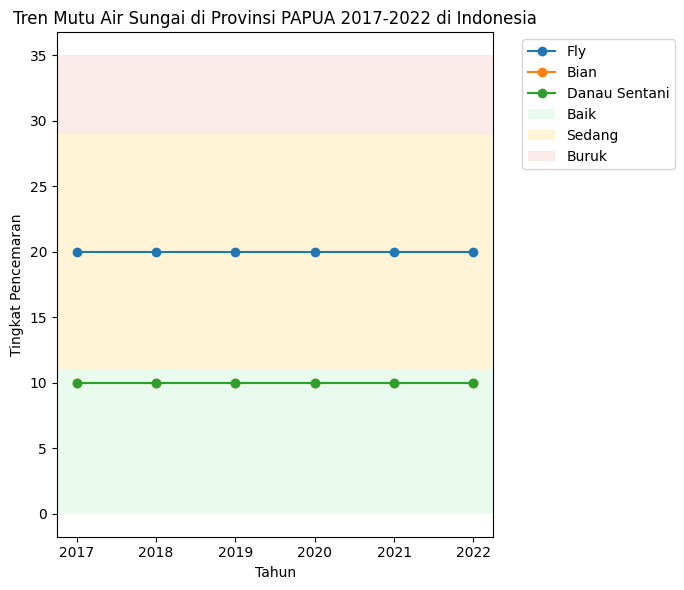

In [68]:
# membuat fungsi untuk plot ke line chart berdasarkan provinsi
def plot_mutu_air(dict):
    tahun = [2017,2018,2019,2020,2021,2022]

    for provinsi, sungai_dict in dict.items():
        plt.figure(figsize=(7, 6))
        for sungai, mutu_list in sungai_dict.items():
            plt.plot(tahun, mutu_list, marker = 'o', label = sungai)

        plt.xlabel('Tahun')
        plt.ylabel('Tingkat Pencemaran')
        plt.title(f'Tren Mutu Air Sungai di Provinsi {provinsi} 2017-2022 di Indonesia')
        plt.axhspan(0,11,facecolor='#c6f5d5',alpha=0.4,label='Baik')
        plt.axhspan(11,29,facecolor='#ffe599',alpha=0.4,label='Sedang')
        plt.axhspan(29,35,facecolor='#f4cccc',alpha=0.4,label='Buruk')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

plot_mutu_air(mutu_dict)

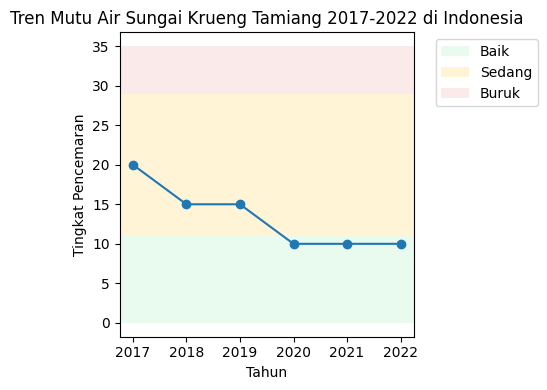

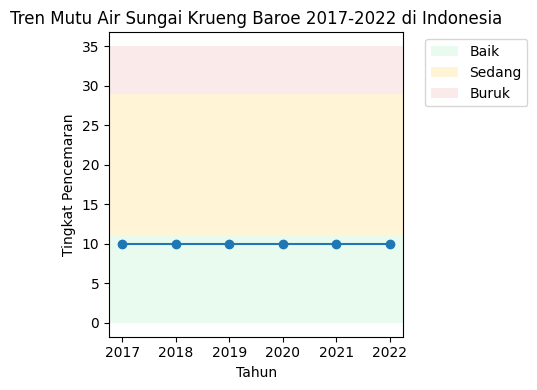

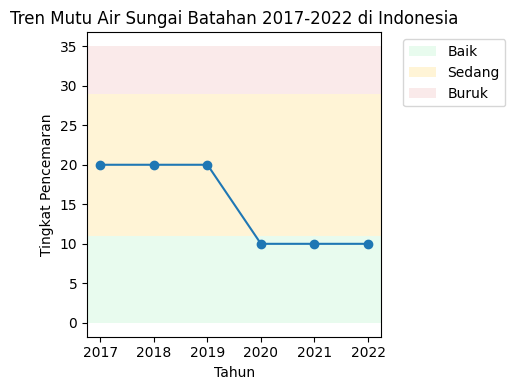

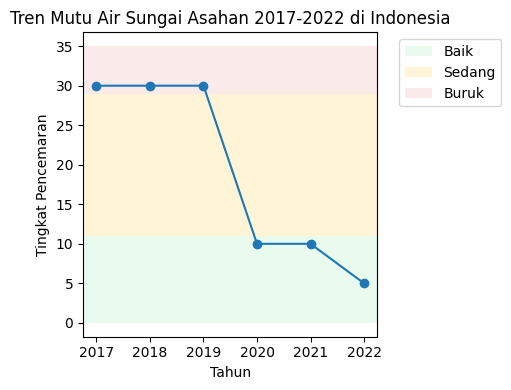

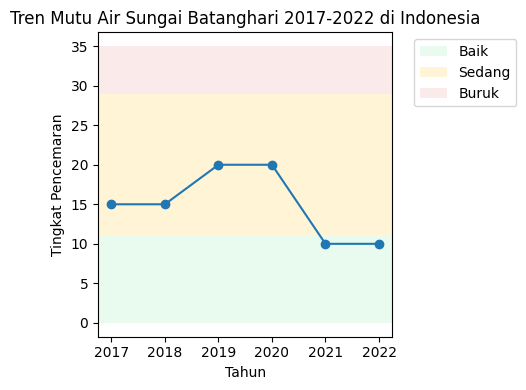

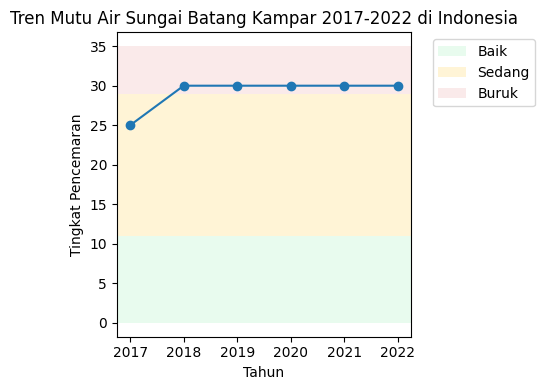

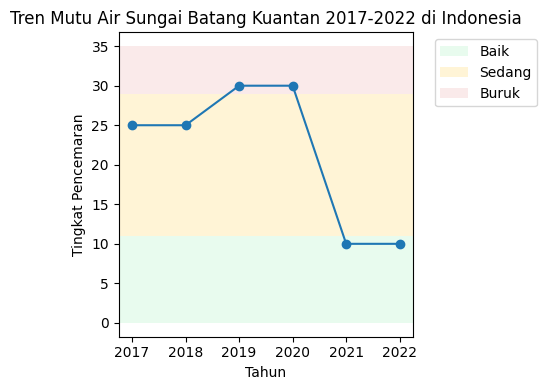

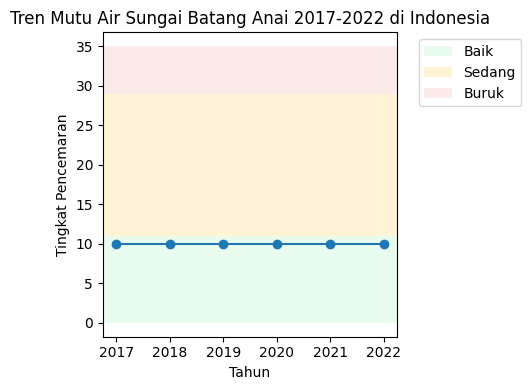

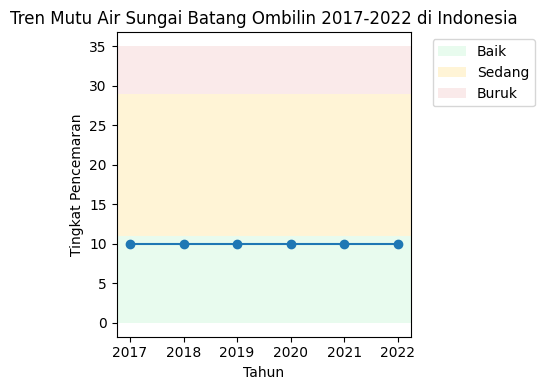

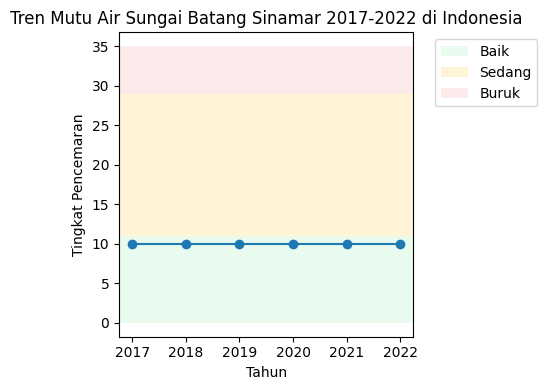

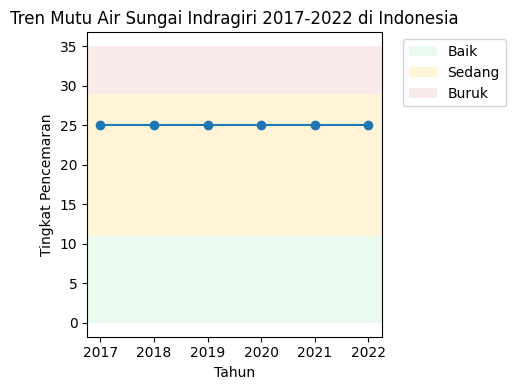

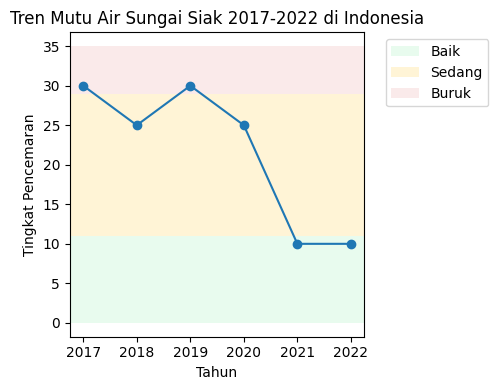

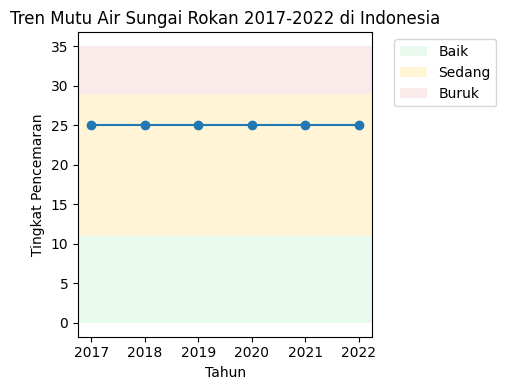

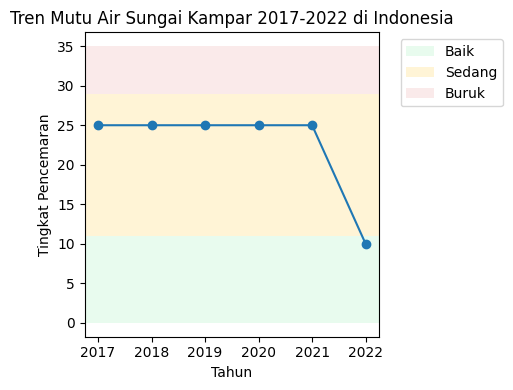

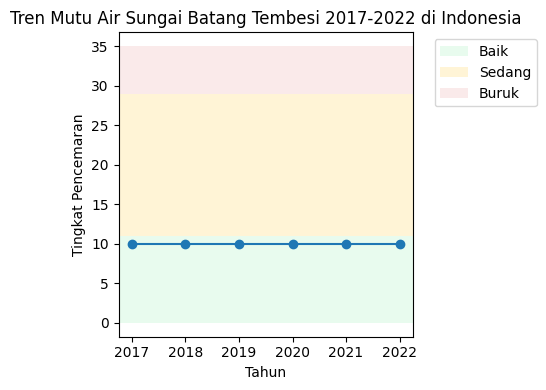

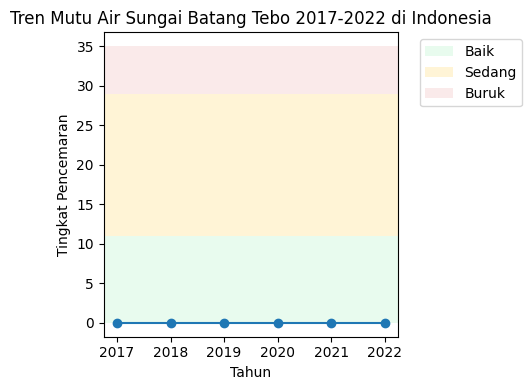

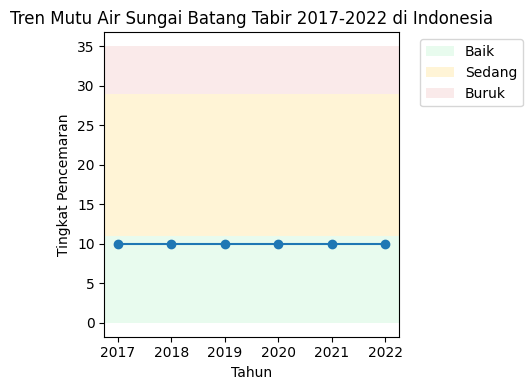

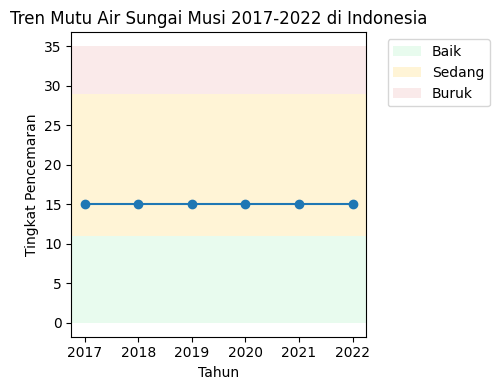

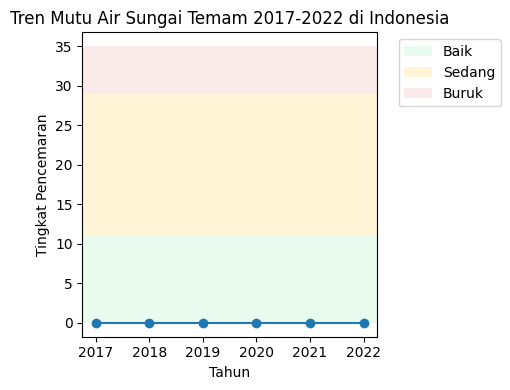

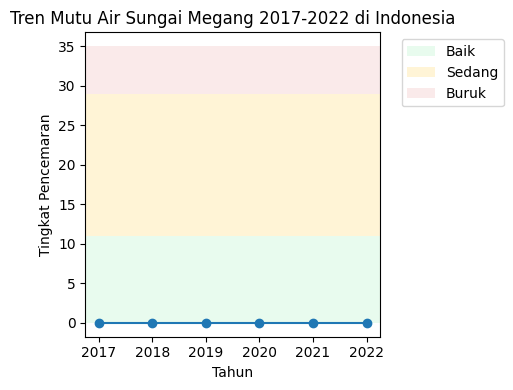

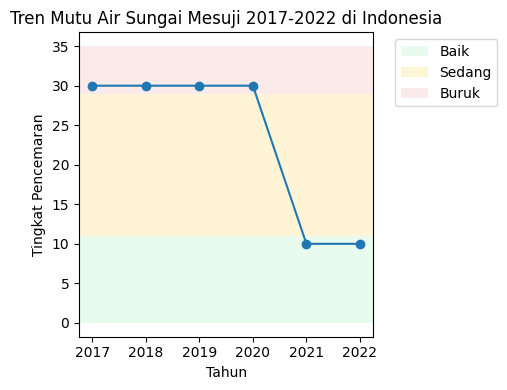

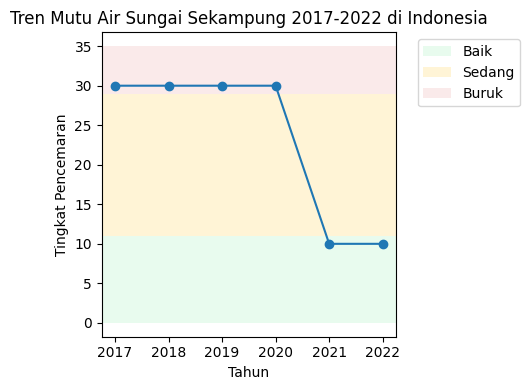

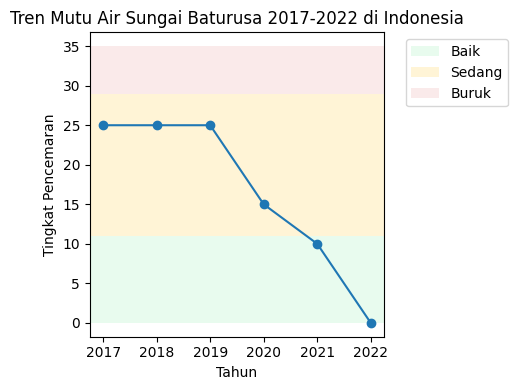

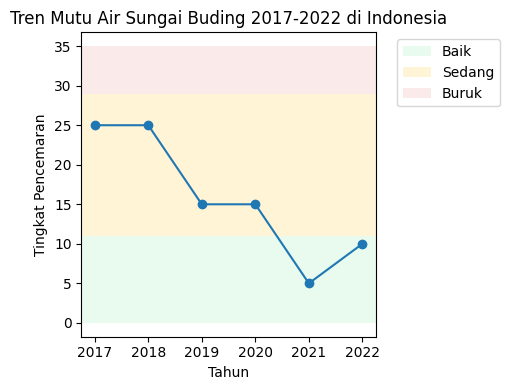

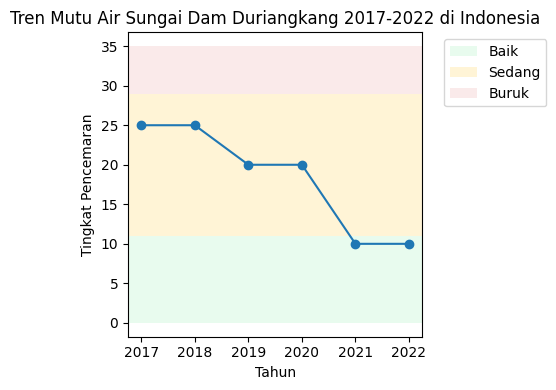

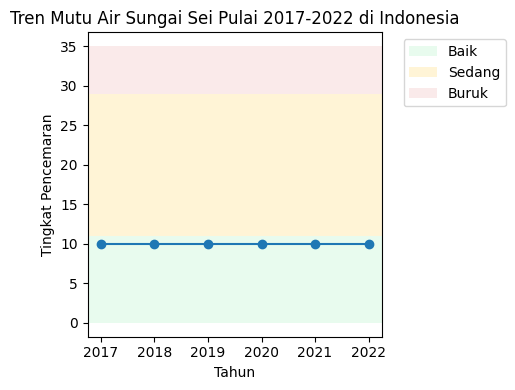

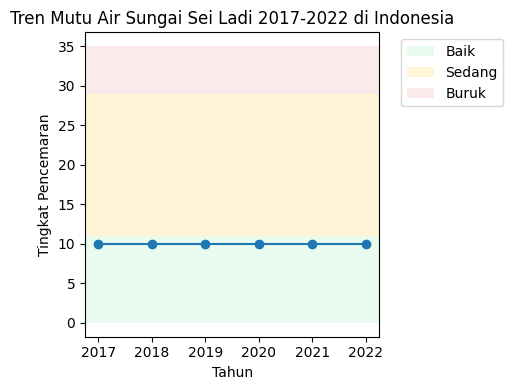

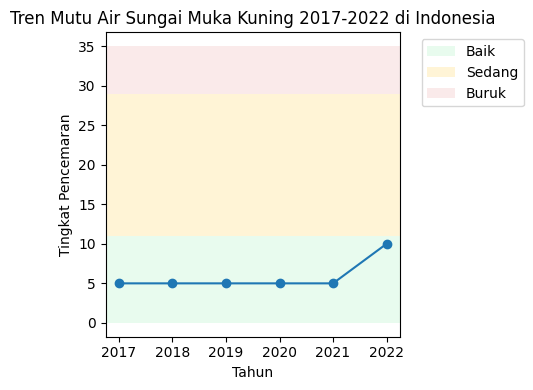

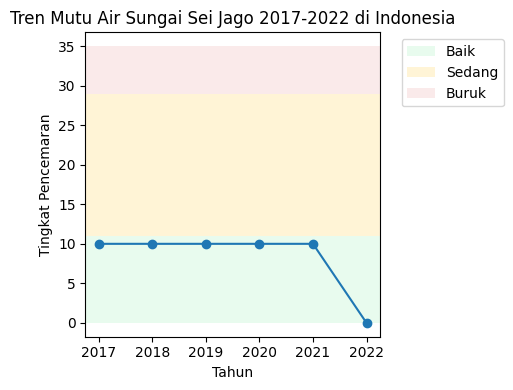

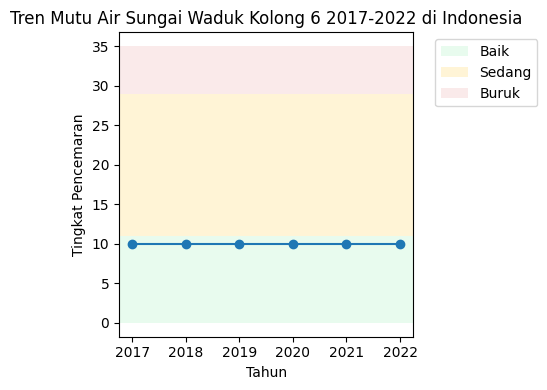

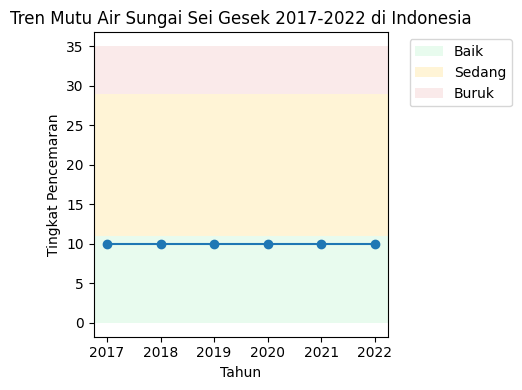

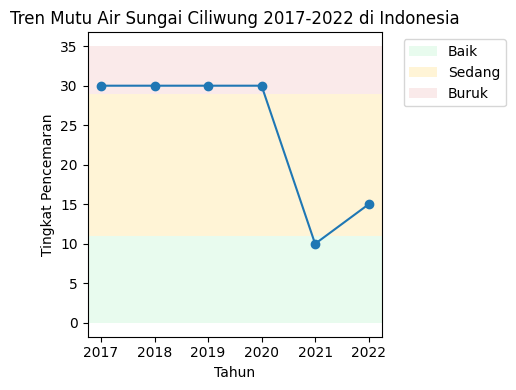

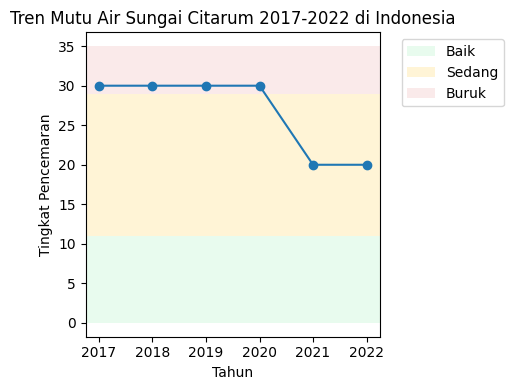

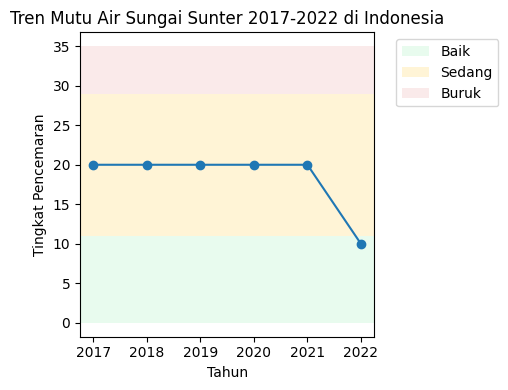

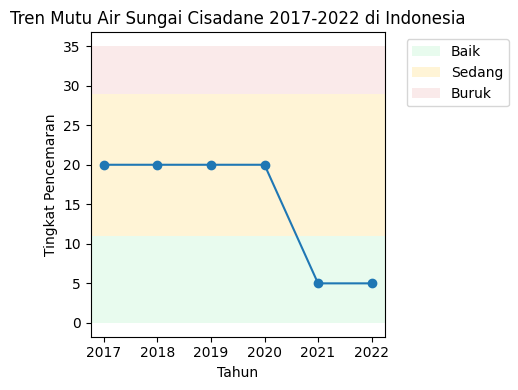

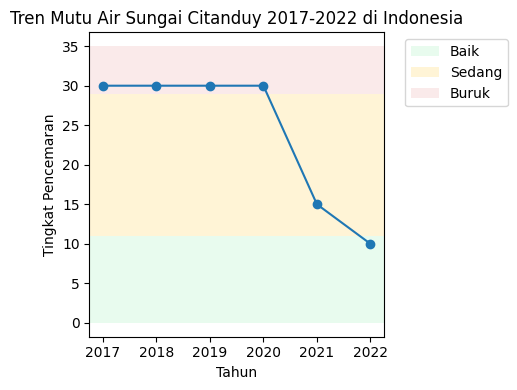

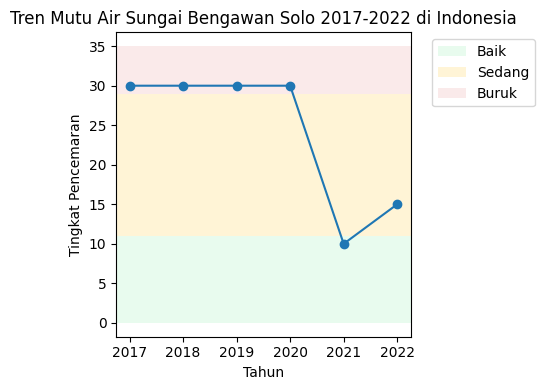

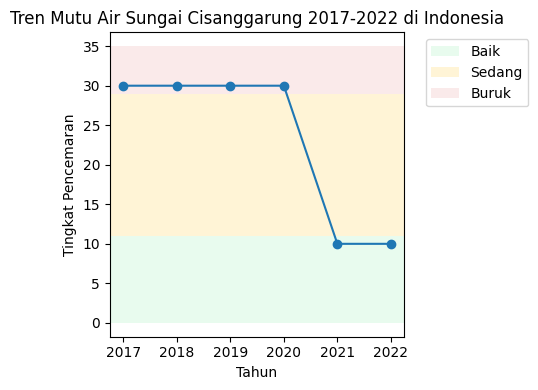

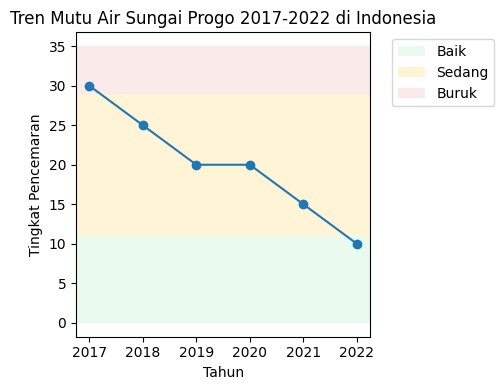

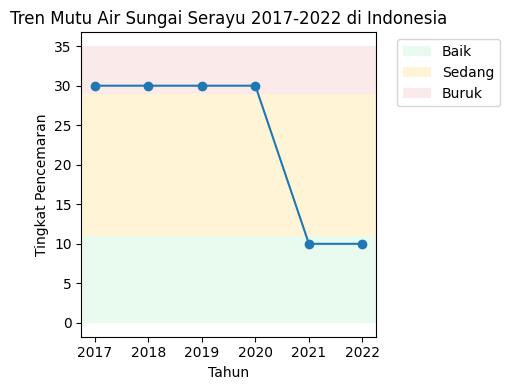

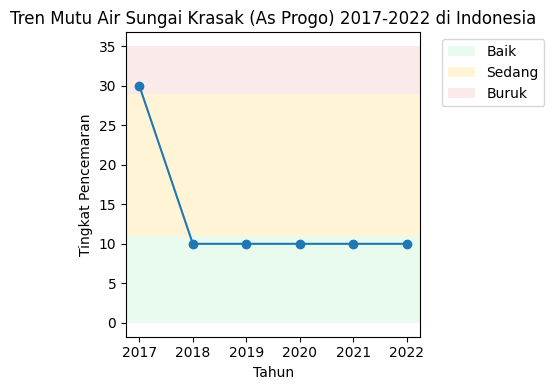

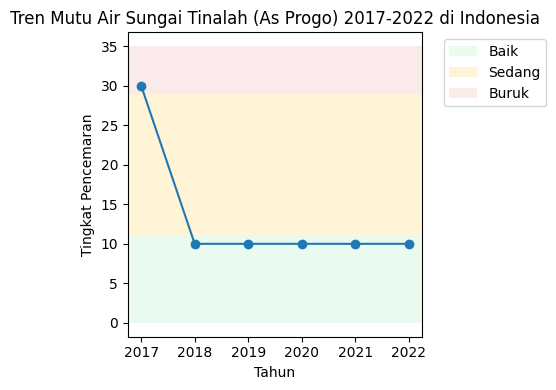

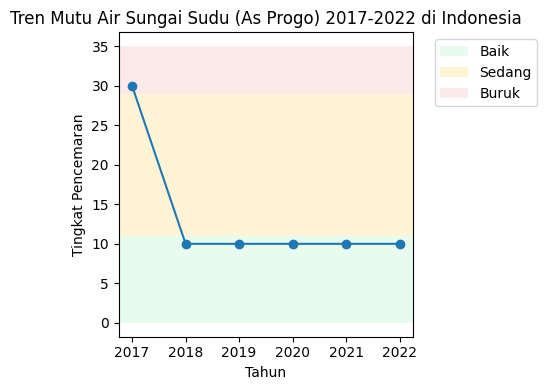

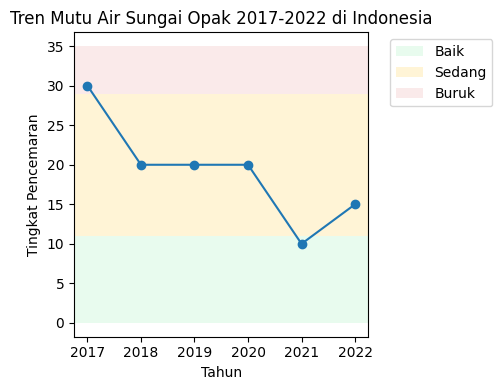

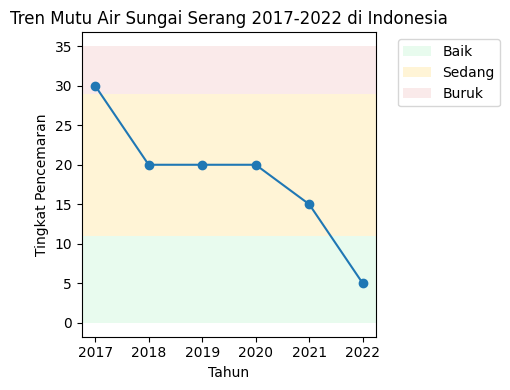

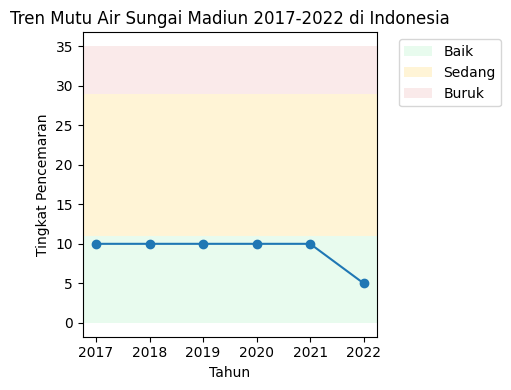

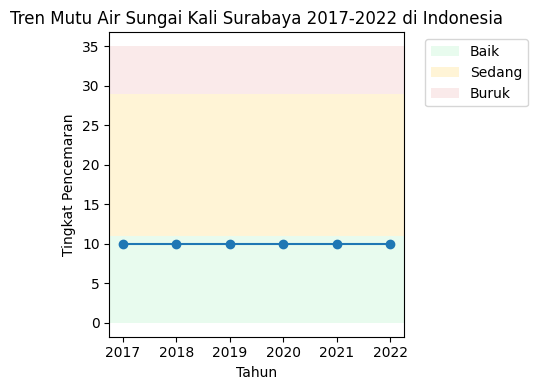

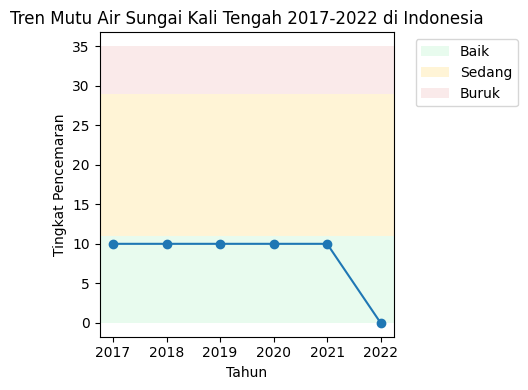

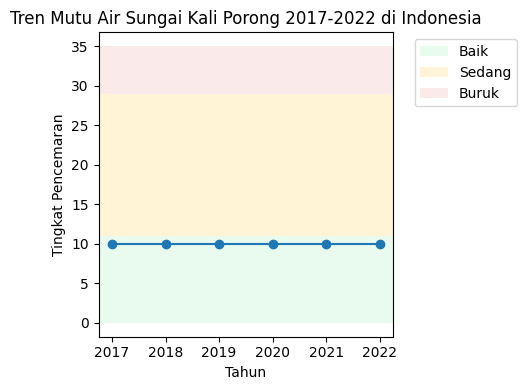

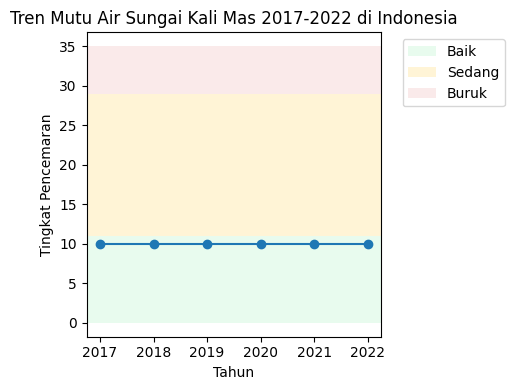

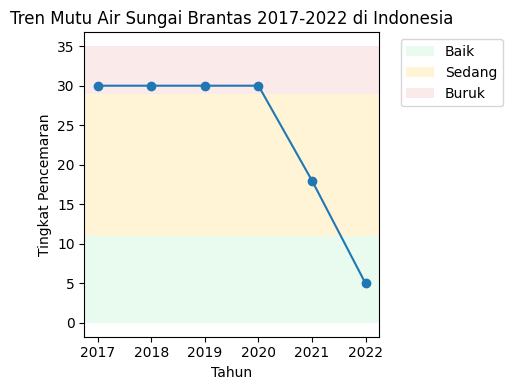

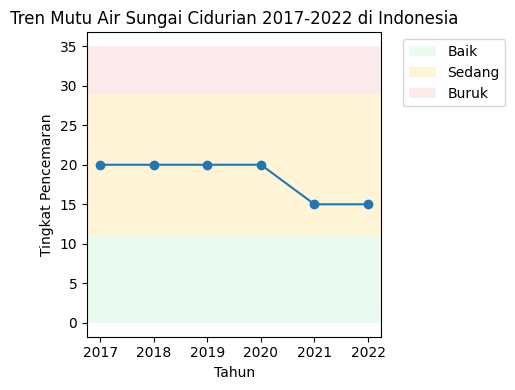

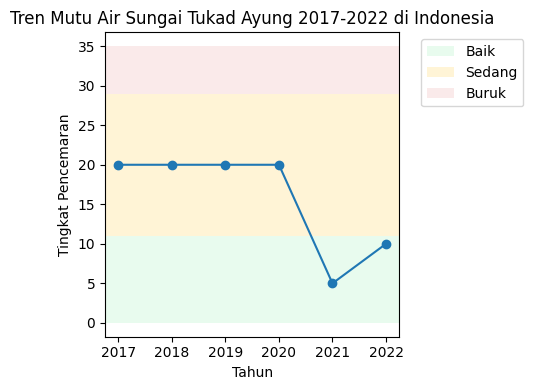

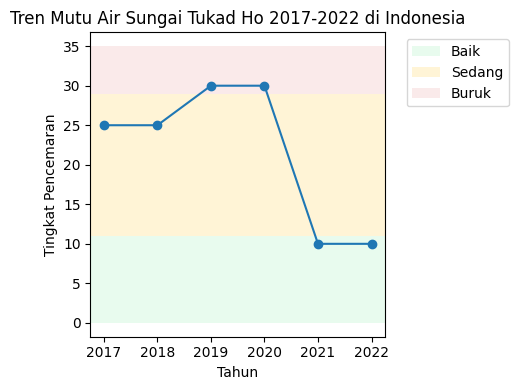

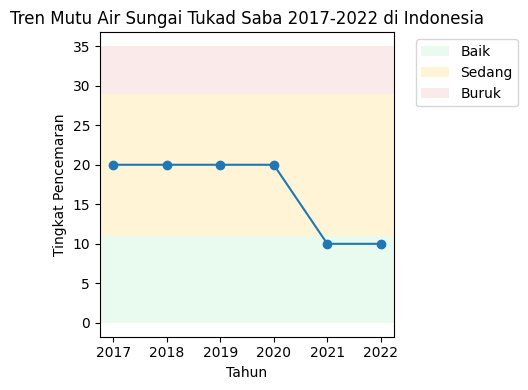

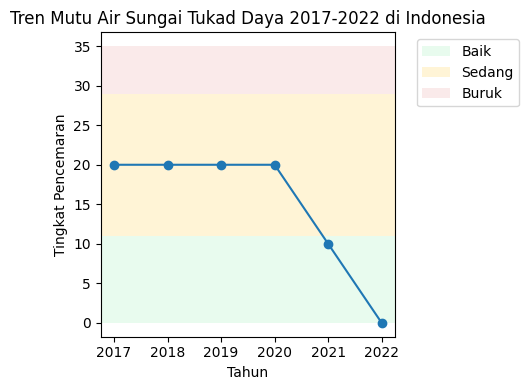

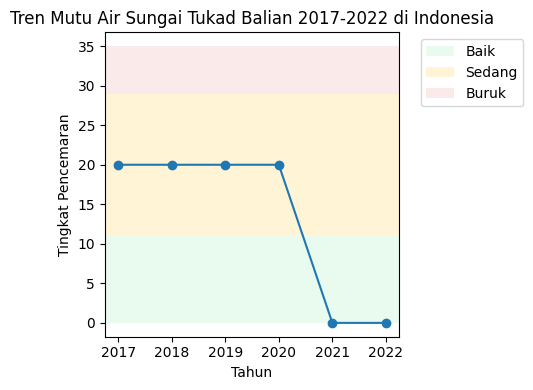

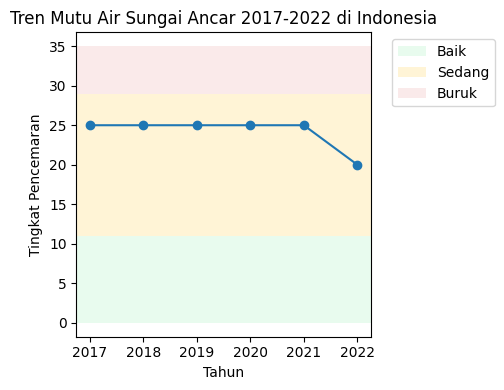

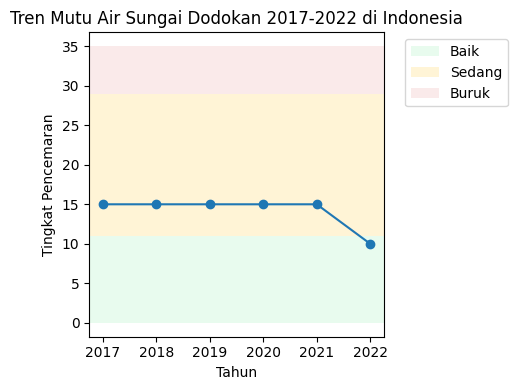

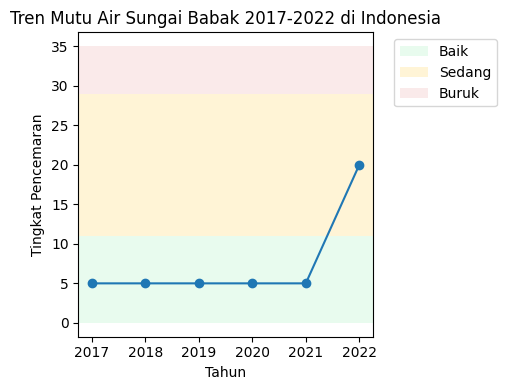

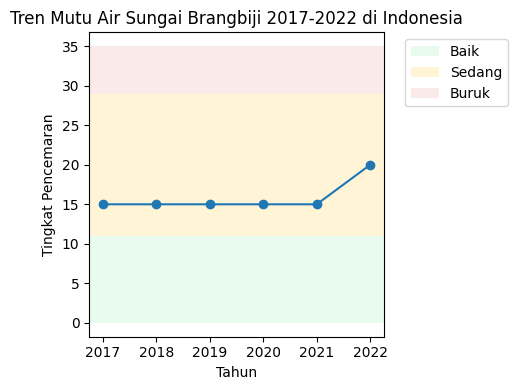

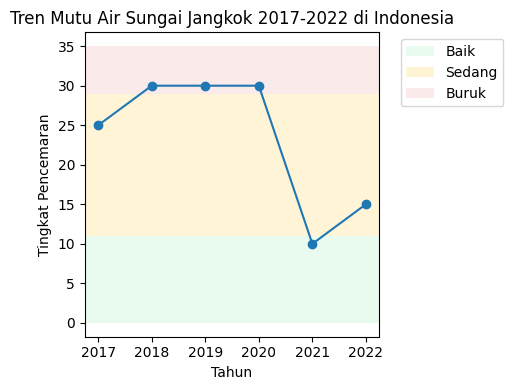

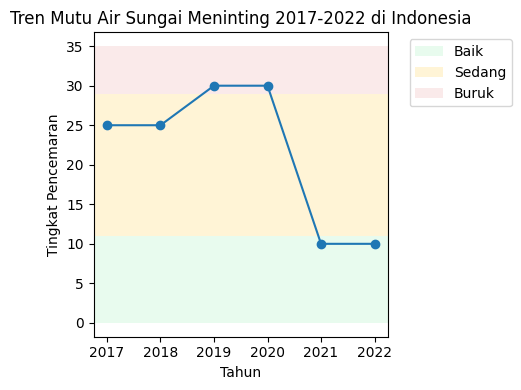

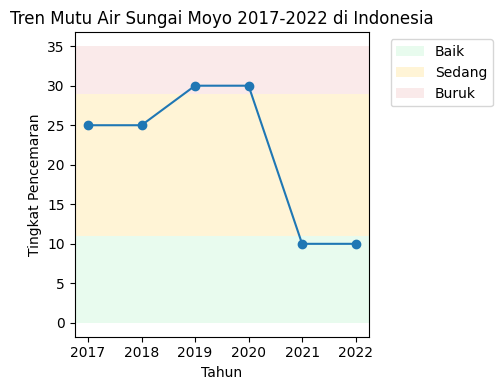

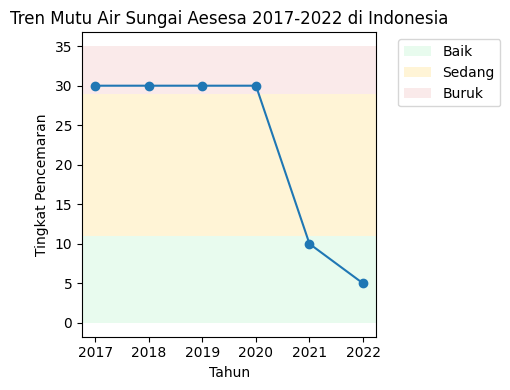

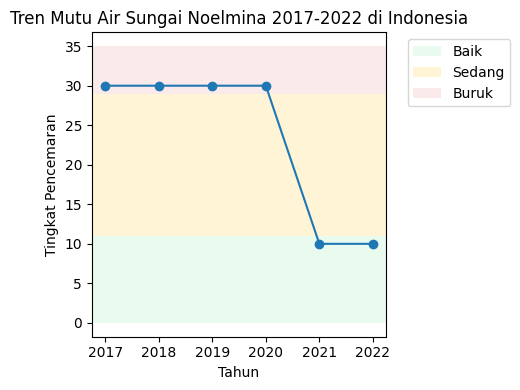

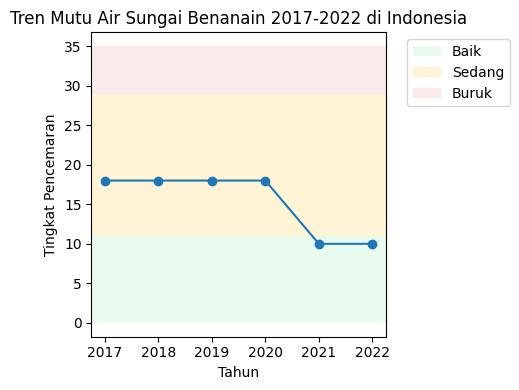

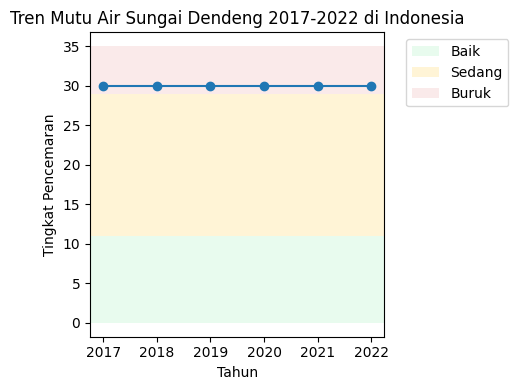

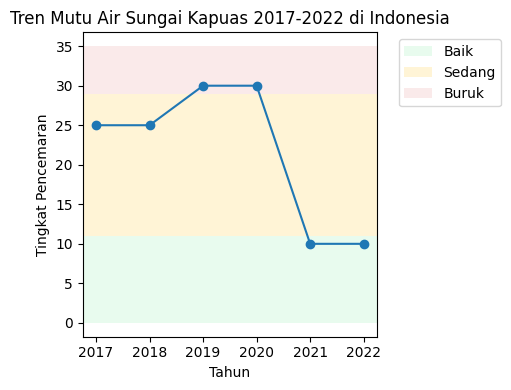

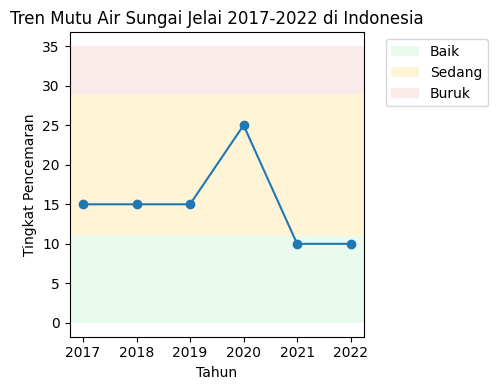

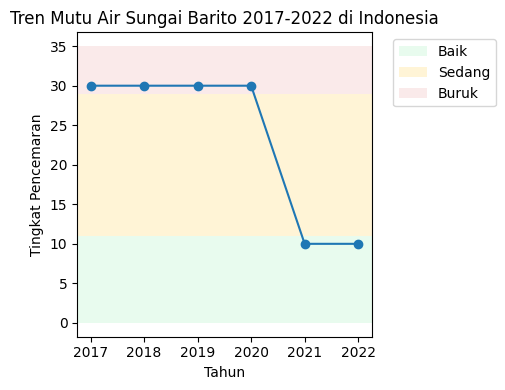

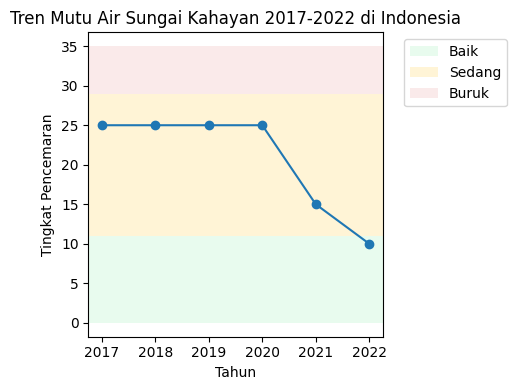

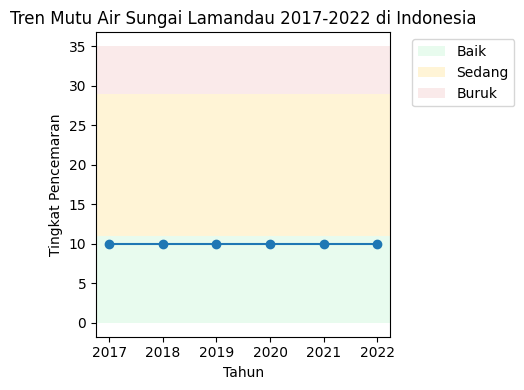

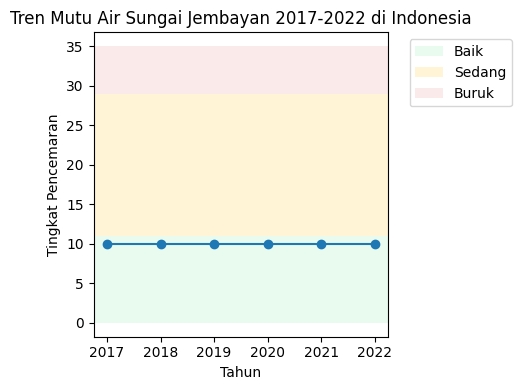

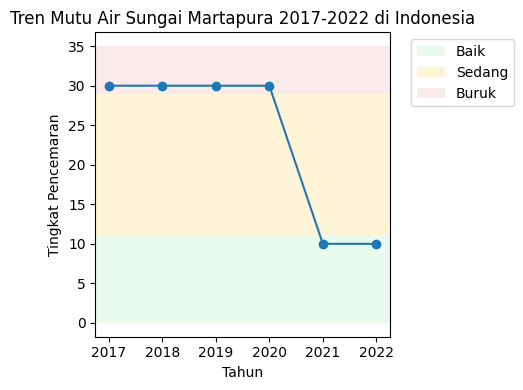

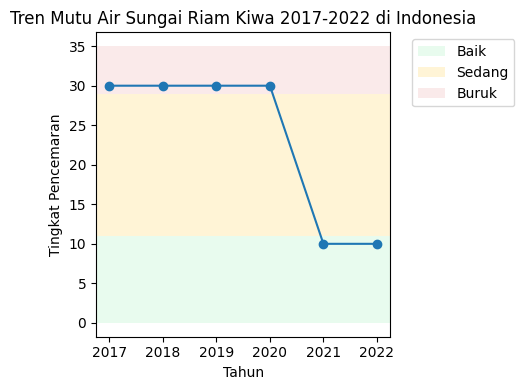

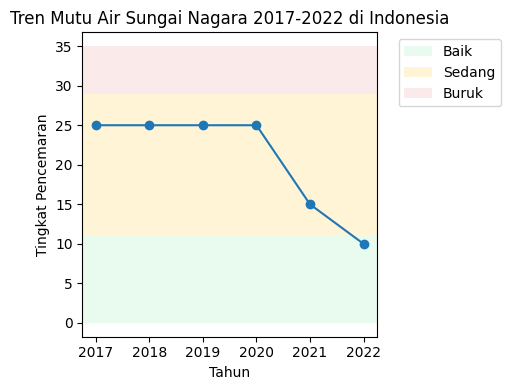

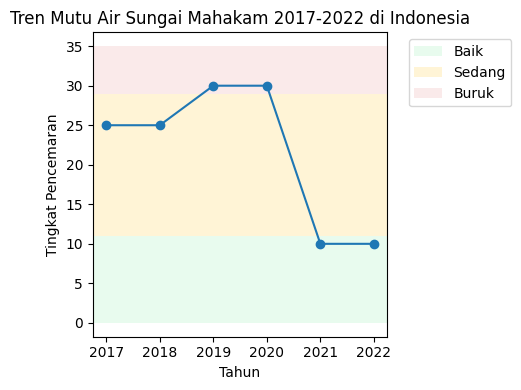

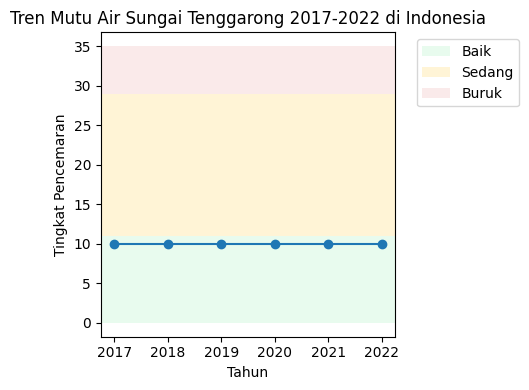

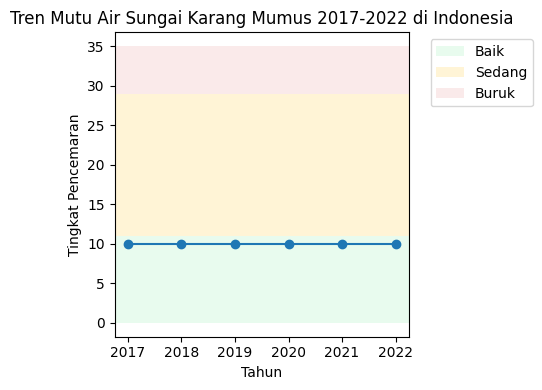

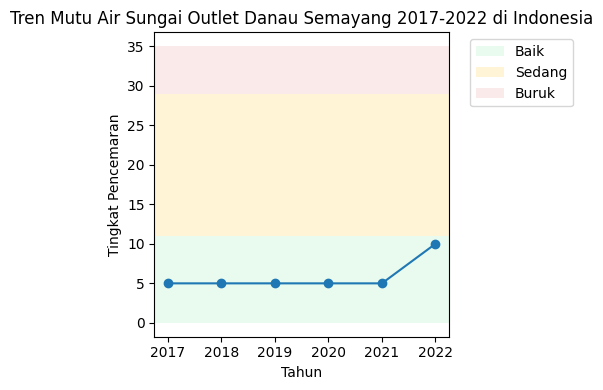

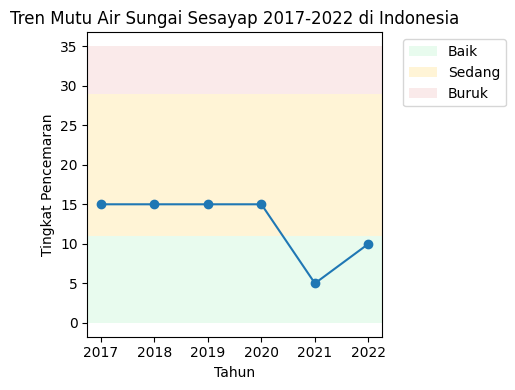

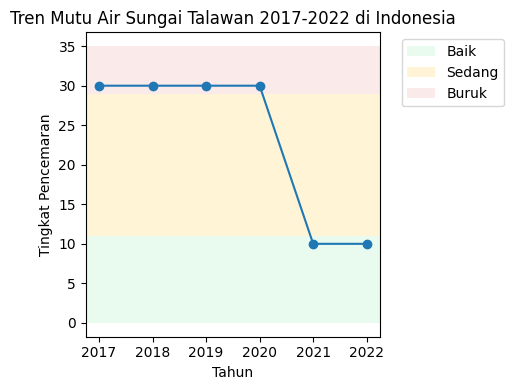

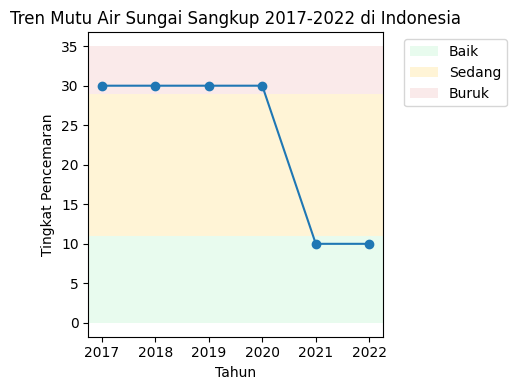

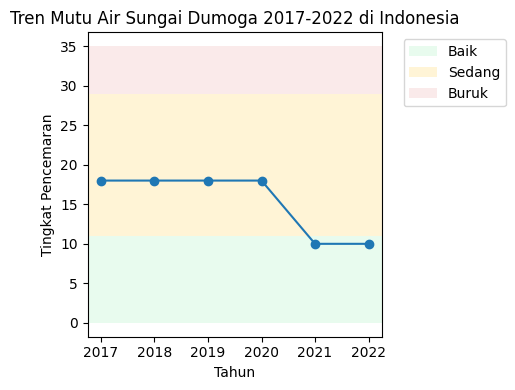

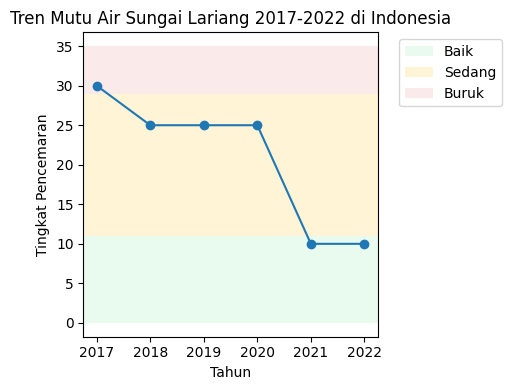

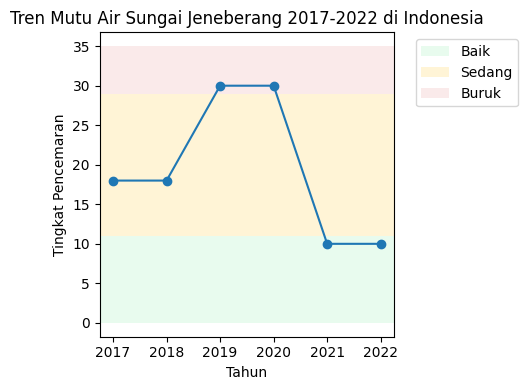

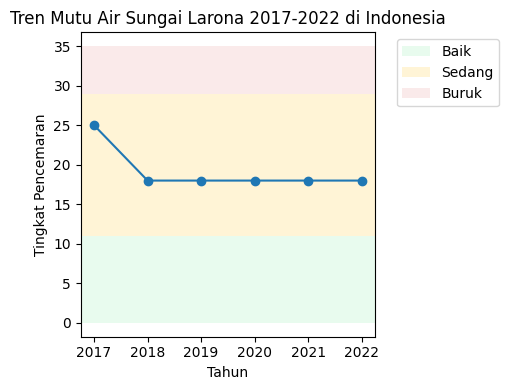

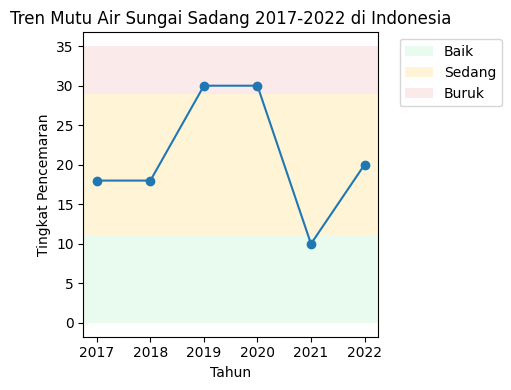

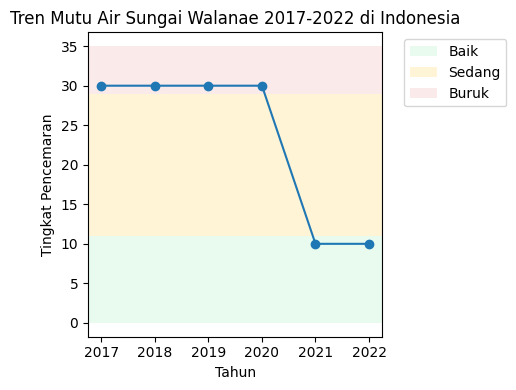

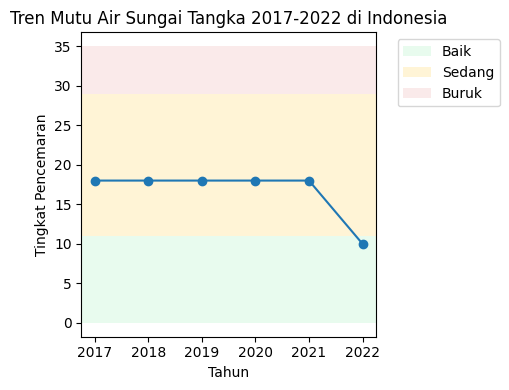

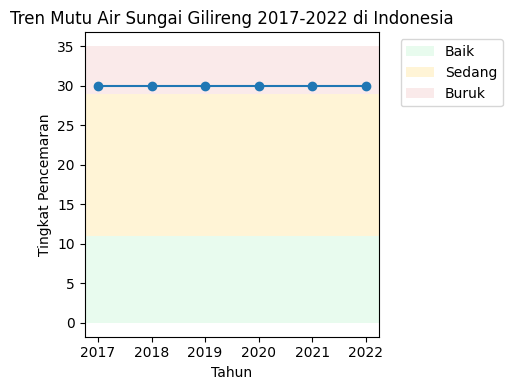

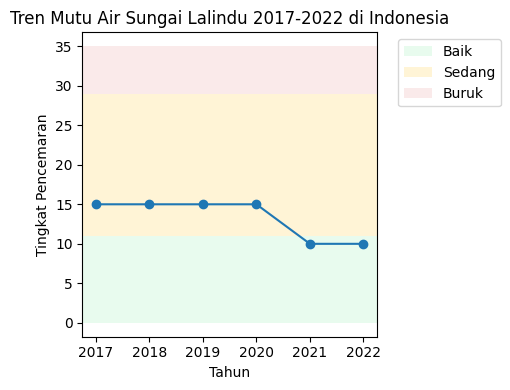

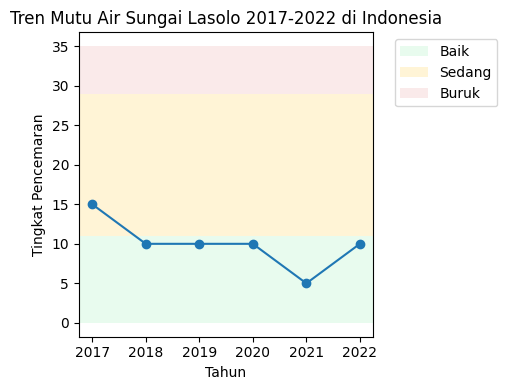

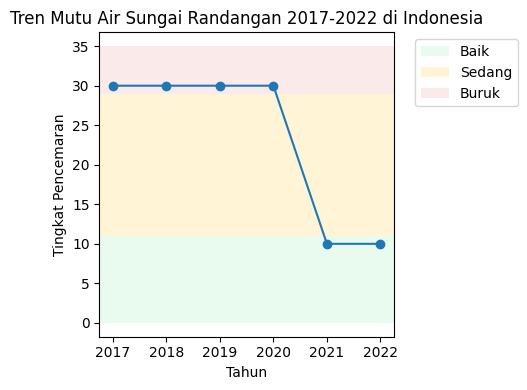

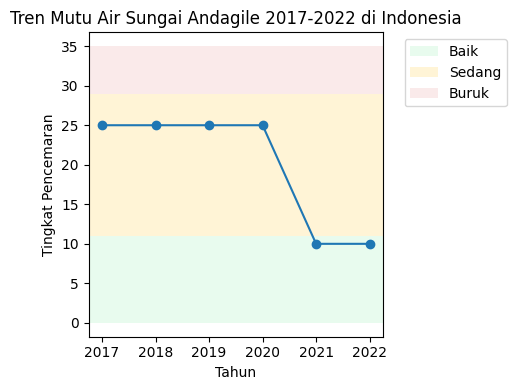

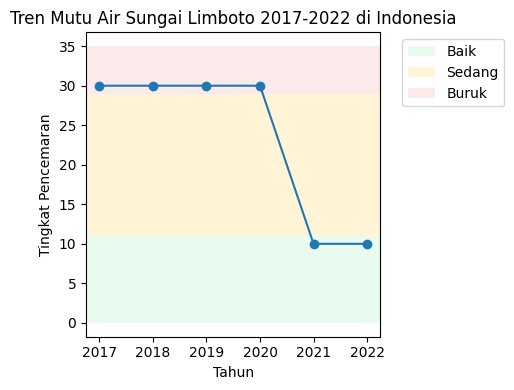

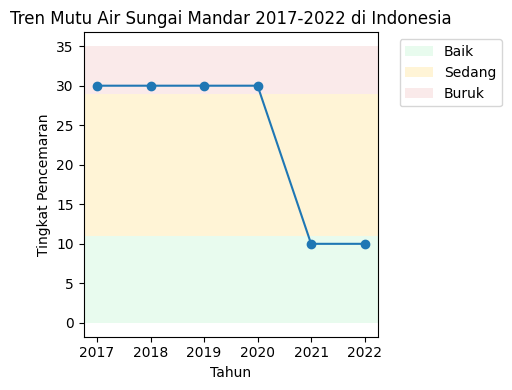

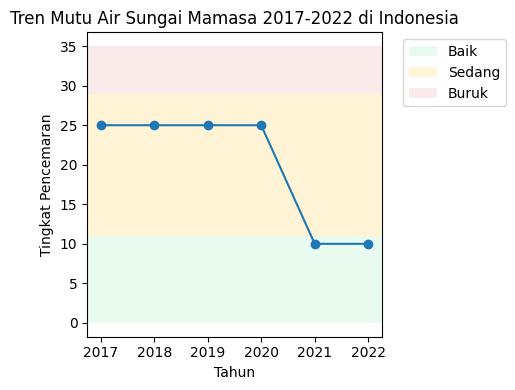

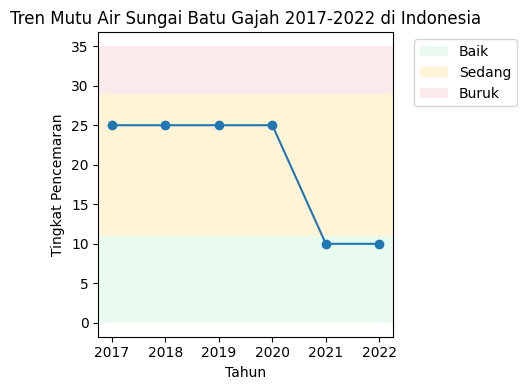

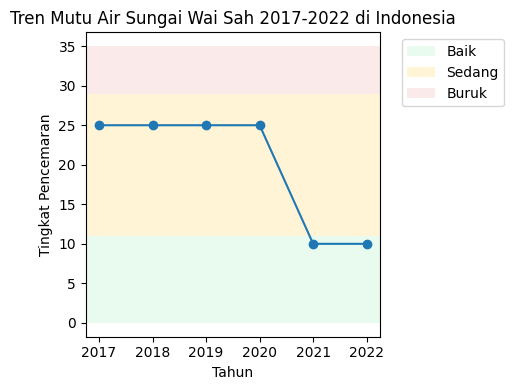

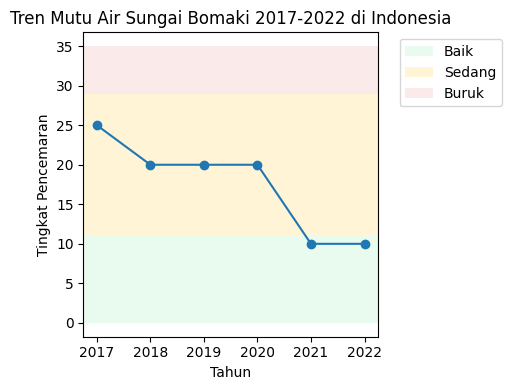

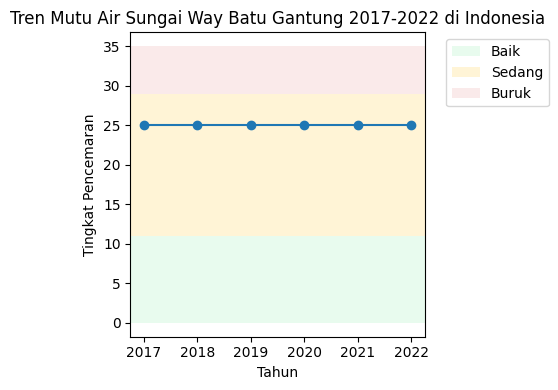

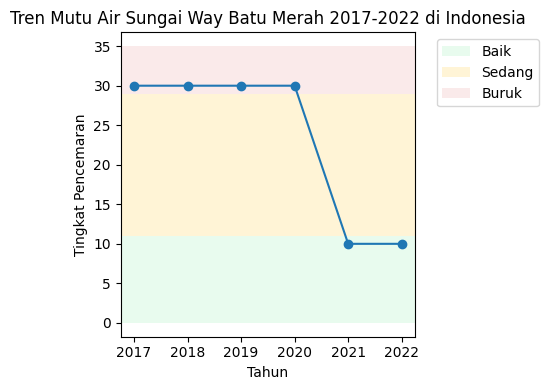

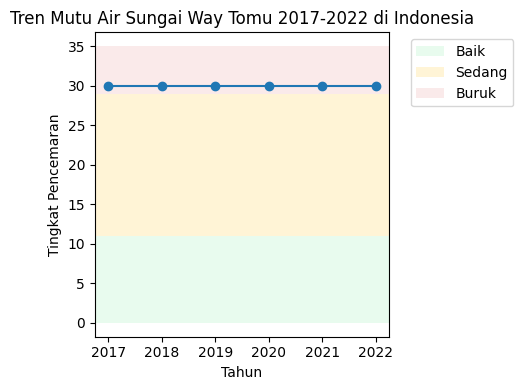

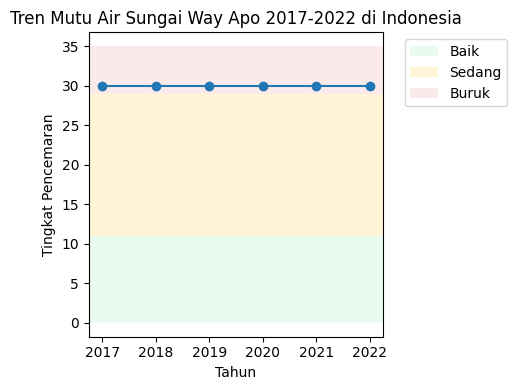

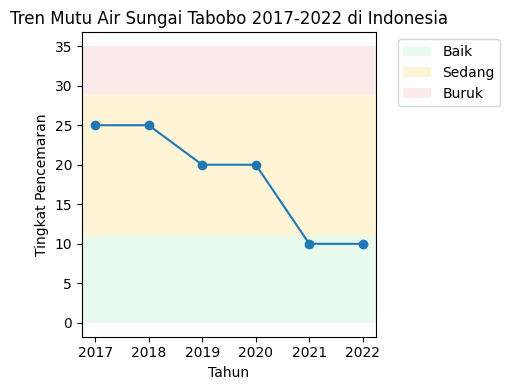

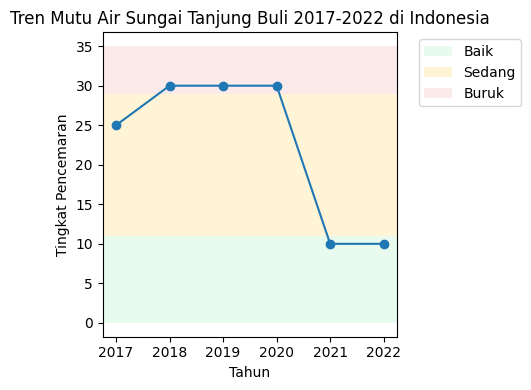

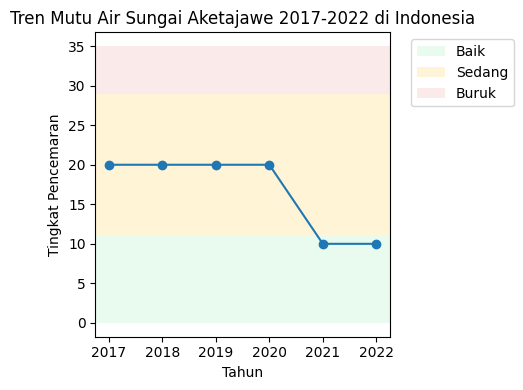

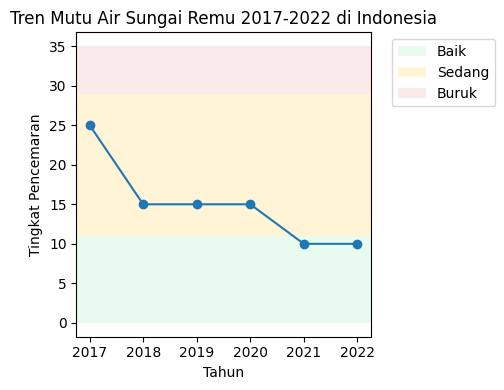

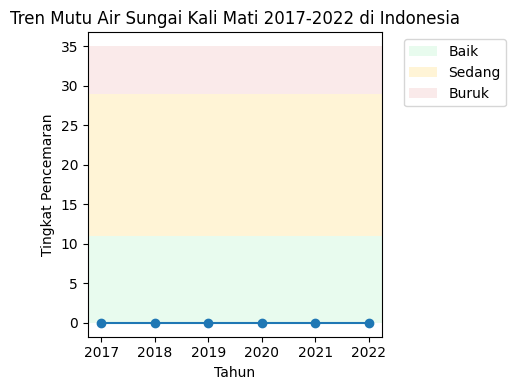

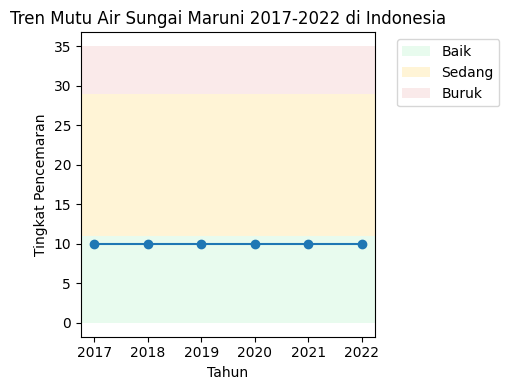

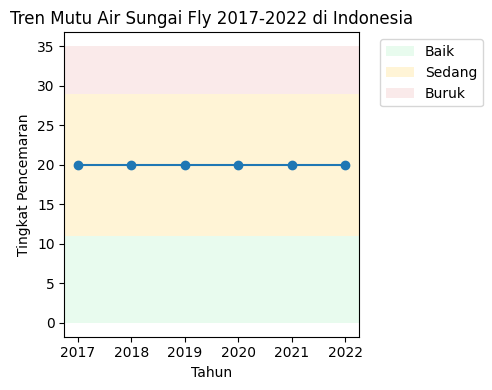

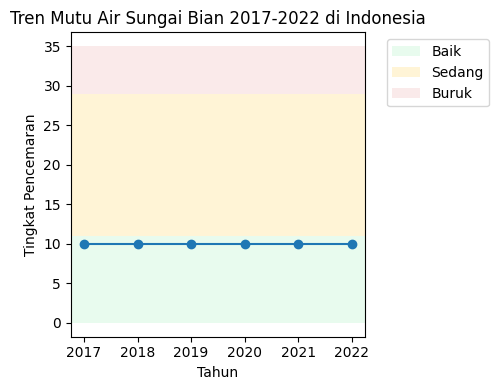

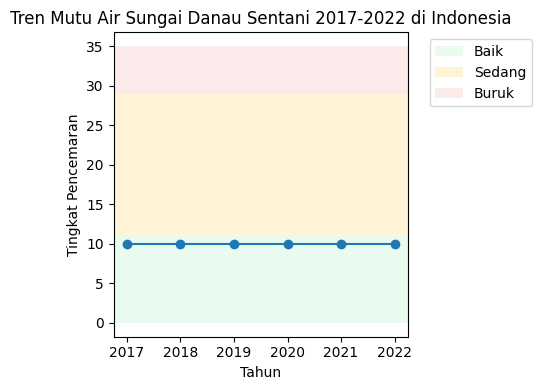

In [69]:
#inisisi dictionary kosong
sungai_dict = {}

# melakukan iterasi pada data di df untuk dimasukkan ke dictionary
for index, row in df.iterrows():
    sungai = row['Sungai']
    mutu_list = [row['2017'],row['2018'],row['2019'],row['2020'],row['2021'],row['2022']]
    sungai_dict[sungai] = mutu_list

# membuat fungsi untuk plot ke line chart per sungai
def plot_sungai(dict):
    tahun = [2017,2018,2019,2020,2021,2022]

    for sungai, mutu_list in dict.items():
        plt.figure(figsize=(5, 4))
        plt.plot(tahun, mutu_list,marker = 'o')

        plt.xlabel('Tahun')
        plt.ylabel('Tingkat Pencemaran')
        plt.title(f'Tren Mutu Air Sungai {sungai} 2017-2022 di Indonesia')
        plt.axhspan(0,11,facecolor='#c6f5d5',alpha=0.4,label='Baik')
        plt.axhspan(11,29,facecolor='#ffe599',alpha=0.4,label='Sedang')
        plt.axhspan(29,35,facecolor='#f4cccc',alpha=0.4,label='Buruk')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

plot_sungai(sungai_dict)
